In [8]:
import ee
import geemap
import os
import rasterio
import numpy as np

In [9]:
ee.Authenticate(auth_mode='localhost')
ee.Initialize(project='worldpeatland')

## Get median VV/VH of Bugoma

In [ ]:
"""
Create S1 Median Composites - Simple Local Download
===================================================
Downloads 2019 and 2024 VH/VV median composites locally
"""

# ===================== DEFINE ROI =====================
bbox = [30.5503711040000994, 1.0709279050000799, 
        31.2229521229999989,1.5469373050000299] # bugoma
roi = ee.Geometry.Rectangle(bbox)

# ===================== SETTINGS =====================
ORBIT_PASS = 'DESCENDING'
RELATIVE_ORBIT = 123
OUTPUT_FOLDER = './s1_medians_bugoma'
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ===================== LOAD 2019 DATA =====================
print("\nLoading 2019 data...")

s1_2019 = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filterDate('2019-01-01', '2019-12-31')
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('orbitProperties_pass', ORBIT_PASS))
    .filter(ee.Filter.eq('relativeOrbitNumber_start', RELATIVE_ORBIT))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .select(['VH', 'VV']))

n_2019 = s1_2019.size().getInfo()
print(f"  Found {n_2019} images")

# Create median
median_2019 = s1_2019.median().clip(roi)
print("  ✓ Median created")

# ===================== LOAD 2024 DATA =====================
print("\nLoading 2024 data...")

s1_2024 = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filterDate('2024-01-01', '2024-12-31')
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('orbitProperties_pass', ORBIT_PASS))
    .filter(ee.Filter.eq('relativeOrbitNumber_start', RELATIVE_ORBIT))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .select(['VH', 'VV']))

n_2024 = s1_2024.size().getInfo()
print(f"  Found {n_2024} images")

# Create median
median_2024 = s1_2024.median().clip(roi)
print("  ✓ Median created")

# ===================== DOWNLOAD 2019 =====================
print("\n" + "="*60)
print("Downloading 2019 median...")
print("="*60)

geemap.ee_export_image(
    median_2019,
    filename=os.path.join(OUTPUT_FOLDER, 's1_median_2019.tif'),
    scale=10,
    region=roi,
    file_per_band=False
)

print(f"✓ Saved: {OUTPUT_FOLDER}/s1_median_2019.tif")

# ===================== DOWNLOAD 2024 =====================
print("\n" + "="*60)
print("Downloading 2024 median...")
print("="*60)

geemap.ee_export_image(
    median_2024,
    filename=os.path.join(OUTPUT_FOLDER, 's1_median_2024.tif'),
    scale=10,
    region=roi,
    file_per_band=False
)

print(f"✓ Saved: {OUTPUT_FOLDER}/s1_median_2024.tif")

# ===================== SUMMARY =====================
print("\n" + "="*60)
print("DONE!")
print("="*60)
print(f"Output folder: {OUTPUT_FOLDER}")
print(f"  2019: {n_2019} images → median (2 bands: VH, VV)")
print(f"  2024: {n_2024} images → median (2 bands: VH, VV)")
print("\nFiles created:")
print(f"  • s1_median_2019.tif")
print(f"  • s1_median_2024.tif")

In [ ]:
"""
Plot S1 Medians - Super Simple
================================
"""

import rasterio
import matplotlib.pyplot as plt

# ===================== LOAD DATA =====================
print("Loading images...")

# Load 2019
with rasterio.open('./s1_medians_bugoma/s1_median_2019.tif') as src:
    vh_2019 = src.read(1)  # Band 1 = VH
    vv_2019 = src.read(2)  # Band 2 = VV

# Load 2024
with rasterio.open('./s1_medians_bugoma/s1_median_2024.tif') as src:
    vh_2024 = src.read(1)
    vv_2024 = src.read(2)

print("✓ Loaded")

# ===================== PLOT =====================
print("Creating plot...")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# VH 2019
axes[0, 0].imshow(vh_2019, cmap='gray', vmin=-25, vmax=-10)
axes[0, 0].set_title('VH 2019', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

# VH 2024
axes[0, 1].imshow(vh_2024, cmap='gray', vmin=-25, vmax=-10)
axes[0, 1].set_title('VH 2024', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

# VV 2019
axes[1, 0].imshow(vv_2019, cmap='gray', vmin=-20, vmax=-5)
axes[1, 0].set_title('VV 2019', fontsize=14, fontweight='bold')
axes[1, 0].axis('off')

# VV 2024
axes[1, 1].imshow(vv_2024, cmap='gray', vmin=-20, vmax=-5)
axes[1, 1].set_title('VV 2024', fontsize=14, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("✓ Done!")

## Test

In [ ]:

# Your extent
# bbox = [30.9254932403564, 1.24946939945221, 
#         30.9698562622070, 1.29278075695038] # test

bbox = [30.5503711040000994, 1.0709279050000799, 
        31.2229521229999989,1.5469373050000299] # bugoma





roi = ee.Geometry.Rectangle(bbox)


In [ ]:
m=geemap.Map(); m.addLayer(ee.Geometry.Rectangle(bbox), {}, "ROI")
m.centerObject(ee.Geometry.Rectangle(bbox), 12)
m

In [ ]:

# Get S1 collection
collection = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(roi) \
    .filterDate('2021-01-01', '2021-12-31') \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
    .select(['VH', 'VV'])

# # Download images
# output_folder = './s1_bugoma_2020_2021'
# os.makedirs(output_folder, exist_ok=True)

# geemap.ee_export_image_collection(collection, out_dir=output_folder, scale=10, region=roi)

In [ ]:
# Get just the first image for testing
# first_image = collection.first()

# Get the LAST image for testing
last_image = collection.sort('system:time_start', False).first()

# Check what we got
print(f"Collection size: {collection.size().getInfo()}")
print(f"First image date: {ee.Date(first_image.get('system:time_start')).format('YYYY-MM-dd').getInfo()}")

# Download single image
output_folder = './s1_bugoma_test2'
os.makedirs(output_folder, exist_ok=True)

geemap.ee_export_image(
    last_image, 
    filename=os.path.join(output_folder, 's1_test2_2021.tif'),
    scale=10, 
    region=roi  
)

print(f"✅ Image exported to {output_folder}")

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Load both images
first_image_path = './s1_bugoma_test/s1_test_2021.tif'
last_image_path = './s1_bugoma_test2/s1_test2_2021.tif'

print("Loading images...")

# Load first image
with rasterio.open(first_image_path) as src:
    vh_first = src.read(1)
    vv_first = src.read(2)
    first_date = "2021-01-03"  # From earlier output

# Load last image
with rasterio.open(last_image_path) as src:
    vh_last = src.read(1)
    vv_last = src.read(2)
    # Get date from metadata if available, or use a placeholder
    last_date = "2021-12-31"  # Approximate

print(f"First image: {first_date}")
print(f"Last image: {last_date}")

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# First image - VH
im1 = axes[0, 0].imshow(vh_first, cmap='gray', vmin=-25, vmax=0)
axes[0, 0].set_title(f'First Image - VH ({first_date})')
axes[0, 0].axis('off')
plt.colorbar(im1, ax=axes[0, 0], label='dB')

# First image - VV
im2 = axes[0, 1].imshow(vv_first, cmap='gray', vmin=-25, vmax=0)
axes[0, 1].set_title(f'First Image - VV ({first_date})')
axes[0, 1].axis('off')
plt.colorbar(im2, ax=axes[0, 1], label='dB')

# Last image - VH
im3 = axes[1, 0].imshow(vh_last, cmap='gray', vmin=-25, vmax=0)
axes[1, 0].set_title(f'Last Image - VH ({last_date})')
axes[1, 0].axis('off')
plt.colorbar(im3, ax=axes[1, 0], label='dB')

# Last image - VV
im4 = axes[1, 1].imshow(vv_last, cmap='gray', vmin=-25, vmax=0)
axes[1, 1].set_title(f'Last Image - VV ({last_date})')
axes[1, 1].axis('off')
plt.colorbar(im4, ax=axes[1, 1], label='dB')

plt.tight_layout()
plt.show()

# Print statistics
print("\nFirst Image Statistics:")
print(f"  VH: min={vh_first.min():.2f}, max={vh_first.max():.2f}, mean={vh_first.mean():.2f}")
print(f"  VV: min={vv_first.min():.2f}, max={vv_first.max():.2f}, mean={vv_first.mean():.2f}")

print("\nLast Image Statistics:")
print(f"  VH: min={vh_last.min():.2f}, max={vh_last.max():.2f}, mean={vh_last.mean():.2f}")

## Main workflow

### Load S1 scenes and Forest baseline

In [51]:
# ===================== 1A: LOAD FOREST MASK =====================
# Your forest mask path
forest_mask_path = "/home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2020.tif"

# Read the forest mask (for reference only)
with rasterio.open(forest_mask_path) as src:
    forest_array = src.read(1)
    forest_crs = src.crs
    
print(f"Forest mask loaded: {forest_array.shape}")
print(f"Forest pixels: {(forest_array == 1).sum()}")

# ===================== USE YOUR SMALL ROI =====================
# Your specified extent 
# bbox = [30.9254932403564, 1.24946939945221, 
#         30.9698562622070, 1.29278075695038]

bbox = [30.9260005950927983,1.2490921020507799, 30.9897918701172017,1.2923980951309200]

roi = ee.Geometry.Rectangle(bbox)

print(f"ROI created from your bbox: {bbox}")

# ===================== 1B: LOAD SENTINEL-1 DATA =====================
START_DATE = '2020-01-01'
END_DATE = '2025-01-01'
POLARIZATION = 'VH'
ORBIT_PASS = 'DESCENDING'
RELATIVE_ORBIT = 123

# Load S1 VV & VH
s1_collection = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('orbitProperties_pass', ORBIT_PASS))
    .filter(ee.Filter.eq('relativeOrbitNumber_start', RELATIVE_ORBIT))
    .select(['VV', 'VH'])  
    .map(lambda img: img.clip(roi))
    .sort('system:time_start'))

Forest mask loaded: (5284, 7508)
Forest pixels: 6068867
ROI created from your bbox: [30.9260005950928, 1.24909210205078, 30.9897918701172, 1.29239809513092]


In [52]:
# Apply speckle filter 
def apply_speckle_filter(image):
    """Apply 5x5 circular filter to reduce speckle"""
    return image.focal_mean(radius=2.5, units='pixels', kernelType='circle')

s1_filtered = s1_collection.map(apply_speckle_filter)

In [ ]:
# ===================== SPECKLE FILTERS =====================
def apply_lee_filter(image):
    """
    Lee Filter (Lee, 1981) - edge-preserving adaptive filter
    Reference: Lee, J.-S. (1981). Refined filtering of image noise using 
               local statistics. Computer Graphics and Image Processing, 15, 380-389.
    """
    radius = 2.5  # 5×5 window
    
    # Calculate local mean
    mean = image.focal_mean(radius=radius, kernelType='circle', units='pixels')
    
    # Calculate local variance: Var = E[X²] - E[X]²
    sqr_mean = image.pow(2).focal_mean(radius=radius, kernelType='circle', units='pixels')
    variance = sqr_mean.subtract(mean.pow(2)).max(0)  # Ensure non-negative
    
    # Lee filter weight (Lee, 1981):
    # W = (σ² - σ_n²) / σ²
    # Equivalently: W = 1 - (σ_n² / σ²)
    # In terms of coefficient of variation: W = (C_i² - C_u²) / C_i²
    
    # C_u = noise coefficient of variation (for intensity images)
    # For 4-look GRD: C_u² = 1/L = 1/4 = 0.25
    cu_squared = 0.25
    
    # C_i² = local coefficient of variation² = σ² / μ²
    ci_squared = variance.divide(mean.pow(2).add(1e-10))
    
    # Weight: W = (C_i² - C_u²) / C_i²
    # Clamp between 0 and 1 to handle homogeneous areas where C_i² < C_u²
    w = ci_squared.subtract(cu_squared).divide(ci_squared.add(1e-10)).clamp(0, 1)
    
    # Filtered output: I_filtered = μ + W × (I - μ)
    filtered = mean.add(w.multiply(image.subtract(mean)))
    
    # Preserve image properties
    return filtered.copyProperties(image, ['system:time_start', 'system:time_end', 'system:index'])

# ===================== APPLY FILTER =====================
s1_lee = s1_collection.map(apply_lee_filter)

radius = 2.5
window_size = int(radius * 2 + 1)
print(f"✓ Lee filter (Lee, 1981) applied ({window_size}×{window_size} window)")

✓ Lee filter (Lee, 1981) applied (6×6 window)


In [56]:
# ===================== QUEGAN & YU - TIME SERIES VERSION =====================
def apply_quegan_timeseries_filter(collection, window_radius=2.5, temporal_window=3):
    """
    Apply Quegan & Yu filter to each image using its temporal neighbors
    Returns a filtered time series (not single image)
    
    Args:
        collection: Input ImageCollection
        window_radius: Spatial window for local mean (2.5 = 5x5)
        temporal_window: Number of neighboring images to use
    """
    img_list = collection.toList(collection.size())
    size = collection.size()
    
    def filter_one_image(i):
        """Filter image i using its temporal neighbors"""
        i = ee.Number(i)
        
        # Get temporal window of images
        start = i.subtract(temporal_window//2).max(0)
        end = i.add(temporal_window//2 + 1).min(size)
        window_imgs = ee.List.sequence(start, end.subtract(1))
        
        # Get the images in this window
        def get_img(idx):
            return ee.Image(img_list.get(idx))
        
        window_collection = ee.ImageCollection(window_imgs.map(get_img))
        
        # Apply Quegan & Yu formula to this window
        # Step 1: Calculate local means
        def add_local_mean(img):
            mean_VV = img.select('VV').focal_mean(radius=window_radius, kernelType='circle', units='pixels')
            mean_VH = img.select('VH').focal_mean(radius=window_radius, kernelType='circle', units='pixels')
            return img.addBands(mean_VV.rename('VV_mean')).addBands(mean_VH.rename('VH_mean'))
        
        with_means = window_collection.map(add_local_mean)
        
        # Step 2: Calculate normalized images and inverse means
        def normalize_img(img):
            # I/μ for each band
            norm_VV = img.select('VV').divide(img.select('VV_mean')).rename('VV_norm')
            norm_VH = img.select('VH').divide(img.select('VH_mean')).rename('VH_norm')
            
            # 1/μ for each band
            inv_VV = ee.Image(1).divide(img.select('VV_mean')).rename('VV_inv')
            inv_VH = ee.Image(1).divide(img.select('VH_mean')).rename('VH_inv')
            
            return img.addBands([norm_VV, norm_VH, inv_VV, inv_VH])
        
        normalized = with_means.map(normalize_img)
        
        # Step 3: Sum across temporal window
        sum_norm_VV = normalized.select('VV_norm').sum()
        sum_norm_VH = normalized.select('VH_norm').sum()
        sum_inv_VV = normalized.select('VV_inv').sum()
        sum_inv_VH = normalized.select('VH_inv').sum()
        
        # Step 4: Filtered result
        filtered_VV = sum_norm_VV.divide(sum_inv_VV).rename('VV')
        filtered_VH = sum_norm_VH.divide(sum_inv_VH).rename('VH')
        
        # Preserve properties from original image
        orig_img = ee.Image(img_list.get(i))
        filtered = filtered_VV.addBands(filtered_VH)
        filtered = filtered.copyProperties(orig_img, ['system:time_start', 'system:time_end', 'system:index'])
        
        return filtered
    
    # Apply to all images
    filtered_list = ee.List.sequence(0, size.subtract(1)).map(filter_one_image)
    return ee.ImageCollection(filtered_list)

# ===================== APPLY TO YOUR DATA =====================
print("Applying Quegan & Yu multitemporal filter (time series version)...")
s1_multitemporal = apply_quegan_timeseries_filter(s1_lee, window_radius=2.5, temporal_window=3)

print(f"✓ Filtered time series created")
print(f"  Input: {s1_lee.size().getInfo()} images")
print(f"  Output: {s1_multitemporal.size().getInfo()} filtered images")

# Verify timestamps preserved
first_time = s1_multitemporal.first().get('system:time_start').getInfo()
print(f"  First timestamp: {first_time}")



Applying Quegan & Yu multitemporal filter (time series version)...
✓ Filtered time series created
  Input: 179 images
  Output: 179 filtered images
  First timestamp: 1578108970000


Array shapes:
  Before: (100, 101), range: [-26.9, -7.2]
  Boxcar: (100, 101), range: [-19.8, -9.7]
  Lee: (100, 101), range: [-19.8, -9.7]
  Multitemporal: (100, 101), range: [-18.8, -10.8]


/tmp/ipykernel_271730/1657106402.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


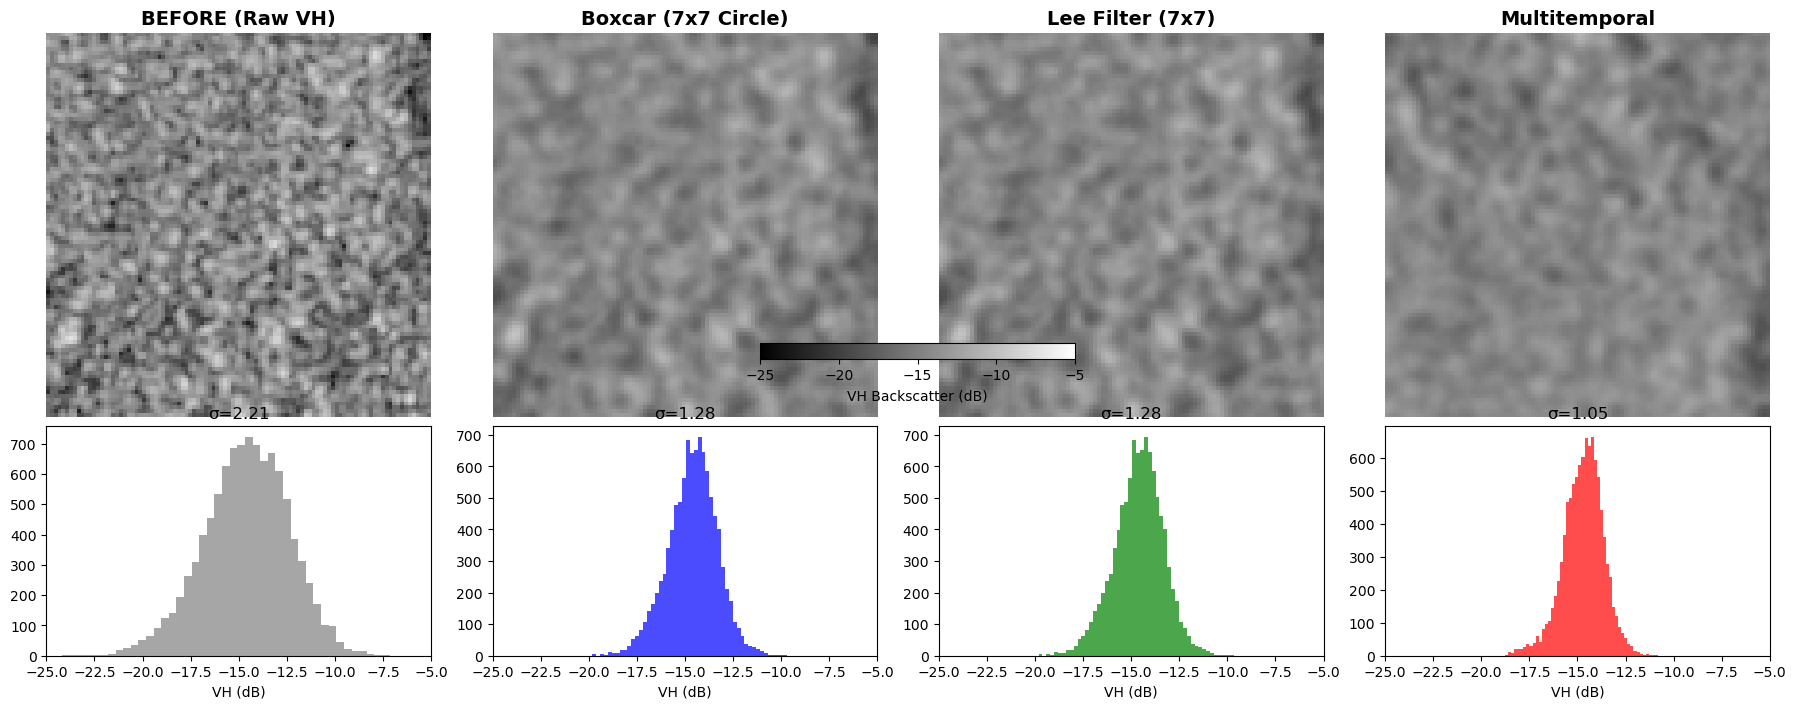


📊 Speckle Reduction (lower σ = better):
  Before:         σ = 2.215
  Boxcar:         σ = 1.284
  Lee:            σ = 1.284
  Multitemporal:  σ = 1.052


In [57]:
import matplotlib.pyplot as plt
import numpy as np

# ===================== GET ONE IMAGE (BEFORE & AFTER) =====================
img_before = s1_collection.first()
img_after = s1_filtered.first()
img_lee = s1_lee.first()
img_multitemporal = s1_multitemporal.first()

# Define sample region
sample_region = ee.Geometry.Point([30.947, 1.271]).buffer(500)

# Get projection from a working image
projection = img_before.select('VH').projection()

# Download the data - REPROJECT multitemporal first
before = img_before.sampleRectangle(region=sample_region, defaultValue=0)
after = img_after.sampleRectangle(region=sample_region, defaultValue=0)
lee = img_lee.sampleRectangle(region=sample_region, defaultValue=0)

# FIX: Reproject multitemporal before sampling
img_multitemporal_fixed = img_multitemporal.reproject(crs=projection, scale=10)
multitemporal = img_multitemporal_fixed.sampleRectangle(region=sample_region, defaultValue=0)

# Convert to numpy
vh_before = np.array(before.get('VH').getInfo())
vh_after = np.array(after.get('VH').getInfo())
vh_lee = np.array(lee.get('VH').getInfo())
vh_multitemporal = np.array(multitemporal.get('VH').getInfo())

print(f"Array shapes:")
print(f"  Before: {vh_before.shape}, range: [{vh_before.min():.1f}, {vh_before.max():.1f}]")
print(f"  Boxcar: {vh_after.shape}, range: [{vh_after.min():.1f}, {vh_after.max():.1f}]")
print(f"  Lee: {vh_lee.shape}, range: [{vh_lee.min():.1f}, {vh_lee.max():.1f}]")
print(f"  Multitemporal: {vh_multitemporal.shape}, range: [{vh_multitemporal.min():.1f}, {vh_multitemporal.max():.1f}]")

# ===================== PLOT WITH COLORBAR =====================
fig, axes = plt.subplots(2, 4, figsize=(18, 10), 
                         gridspec_kw={'height_ratios': [3, 1]})

# Top row: Images
vmin, vmax = -25, -5

im1 = axes[0,0].imshow(vh_before[:100, :100], cmap='gray', vmin=vmin, vmax=vmax)
axes[0,0].set_title('BEFORE (Raw VH)', fontsize=14, fontweight='bold')
axes[0,0].axis('off')

im2 = axes[0,1].imshow(vh_after[:100, :100], cmap='gray', vmin=vmin, vmax=vmax)
axes[0,1].set_title('Boxcar (7x7 Circle)', fontsize=14, fontweight='bold')
axes[0,1].axis('off')

im3 = axes[0,2].imshow(vh_lee[:100, :100], cmap='gray', vmin=vmin, vmax=vmax)
axes[0,2].set_title('Lee Filter (7x7)', fontsize=14, fontweight='bold')
axes[0,2].axis('off')

im4 = axes[0,3].imshow(vh_multitemporal[:100, :100], cmap='gray', vmin=vmin, vmax=vmax)
axes[0,3].set_title('Multitemporal', fontsize=14, fontweight='bold')
axes[0,3].axis('off')

# Bottom row: Histograms
axes[1,0].hist(vh_before[:100, :100].flatten(), bins=50, color='gray', alpha=0.7)
axes[1,0].set_xlabel('VH (dB)')
axes[1,0].set_xlim(vmin, vmax)
axes[1,0].set_title(f'σ={vh_before[:100, :100].std():.2f}')

axes[1,1].hist(vh_after[:100, :100].flatten(), bins=50, color='blue', alpha=0.7)
axes[1,1].set_xlabel('VH (dB)')
axes[1,1].set_xlim(vmin, vmax)
axes[1,1].set_title(f'σ={vh_after[:100, :100].std():.2f}')

axes[1,2].hist(vh_lee[:100, :100].flatten(), bins=50, color='green', alpha=0.7)
axes[1,2].set_xlabel('VH (dB)')
axes[1,2].set_xlim(vmin, vmax)
axes[1,2].set_title(f'σ={vh_lee[:100, :100].std():.2f}')

axes[1,3].hist(vh_multitemporal[:100, :100].flatten(), bins=50, color='red', alpha=0.7)
axes[1,3].set_xlabel('VH (dB)')
axes[1,3].set_xlim(vmin, vmax)
axes[1,3].set_title(f'σ={vh_multitemporal[:100, :100].std():.2f}')

# Add colorbar
fig.colorbar(im4, ax=axes[0,:], orientation='horizontal', 
             label='VH Backscatter (dB)', pad=0.02, fraction=0.03)

plt.tight_layout()
plt.show()

print(f"\n📊 Speckle Reduction (lower σ = better):")
print(f"  Before:         σ = {vh_before[:100, :100].std():.3f}")
print(f"  Boxcar:         σ = {vh_after[:100, :100].std():.3f}")
print(f"  Lee:            σ = {vh_lee[:100, :100].std():.3f}")
print(f"  Multitemporal:  σ = {vh_multitemporal[:100, :100].std():.3f}")

## === Temporal Variability ===



In [58]:
# ===================== LOAD FOREST MASK =====================
forest_mask_gee = ee.Image('projects/worldpeatland/assets/forest_extent_bugoma_2020_32636')
forest_mask_gee = forest_mask_gee.select('b1').gt(0).clip(roi).rename('forest')

print("✓ Forest mask loaded from Earth Engine asset")

✓ Forest mask loaded from Earth Engine asset


In [59]:
"""
STEP 2: Calculate Temporal Variability
=======================================
"""

print("="*60)
print("STEP 2: Temporal Variability")
print("="*60)

# s1_vh = s1_lee.select('VH')
s1_vh = s1_multitemporal.select('VH')

# ===================== CALCULATE STATISTICS =====================
print("\nCalculating temporal statistics...")

std_dev = s1_vh.reduce(ee.Reducer.stdDev()).rename('stdDev')
p95 = s1_vh.reduce(ee.Reducer.percentile([95])).rename('p95')
p05 = s1_vh.reduce(ee.Reducer.percentile([5])).rename('p05')

print("✓ Statistics calculated")

# ===================== THRESHOLD SELECTION =====================
# ⚙️ CHOOSE YOUR METHOD:

USE_FIXED_SIGMA = True  # ← Set to True for manual sigma, False for percentile

if USE_FIXED_SIGMA:
    # Manual sigma threshold (dB)
    tv_threshold = 0.3  # ← Adjust this value!
    print(f"\n✓ Using FIXED sigma threshold: {tv_threshold:.3f} dB")
    
else:
    # Automatic percentile threshold
    TV_PERCENTILE = 85  # ← Adjust percentile if needed
    tv_threshold = std_dev.updateMask(forest_mask_gee).reduceRegion(
        reducer=ee.Reducer.percentile([TV_PERCENTILE]),
        geometry=roi,
        scale=10,
        maxPixels=1e10
    ).getInfo()
    tv_threshold = list(tv_threshold.values())[0]
    print(f"\n✓ Using PERCENTILE threshold (p{TV_PERCENTILE}): {tv_threshold:.3f} dB")

# ===================== FIND CANDIDATE PIXELS =====================
# Create candidate mask
candidate_mask = std_dev.gte(tv_threshold).rename('candidates')

# Count candidates
n_candidates = candidate_mask.updateMask(forest_mask_gee).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=roi,
    scale=10,
    maxPixels=1e10
).getInfo().get('candidates', 0)

# Calculate percentage
n_forest = forest_mask_gee.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=roi,
    scale=10,
    maxPixels=1e10
).getInfo().get('b1', 0)

candidate_percent = (n_candidates / n_forest * 100) if n_forest > 0 else 0

print(f"Candidate pixels: {int(n_candidates)} ({candidate_percent:.1f}% of forest)")
print("\n✓ Ready for step 3")

STEP 2: Temporal Variability

Calculating temporal statistics...
✓ Statistics calculated

✓ Using FIXED sigma threshold: 0.300 dB
Candidate pixels: 301944 (0.0% of forest)

✓ Ready for step 3


## ---Logistic Fitting---

In [ ]:
# """
# STEP 3: Fit Logistic Function - WITH SSE FILTER
# ================================================
# Now steepness and window actually matter!
# """

# import ee

# print("="*60)
# print("STEP 3: Logistic Fitting with SSE Filter")
# print("="*60)

# # ===================== PREPARE TIME SERIES =====================
# M = s1_vh.size().getInfo()
# print(f"\nTime series length: {M} images")

# stack = s1_vh.toArray()
# y_array = stack.arrayProject([0])
# obs_idx = ee.Image.constant(ee.Array(ee.List.sequence(0, M - 1))).toArray()

# # ===================== CALCULATE PARAMETERS =====================
# amp = p95.subtract(p05).rename('amp')
# lower = p05
# flattening = amp.divide(p95.abs()).rename('flattening')

# print("✓ Parameters calculated")

# # ===================== FIND INFLECTION POINTS =====================
# A_STEEPNESS = -2
# N_WINDOW = 5
# SSE_THRESHOLD = 0.05  # NEW: Only accept good fits

# idx_min = N_WINDOW
# idx_max = M - N_WINDOW - 1
# t0_list = list(range(idx_min, idx_max + 1))

# print(f"Testing {len(t0_list)} inflection points...")

# def calculate_sse(y_array, obs_idx, lower, amp, t0, a, n_window):
#     """Calculate SSE for logistic fit at time t0"""
#     t0 = ee.Number(t0)
    
#     exponent = obs_idx.subtract(t0).multiply(-a)
#     denom = exponent.exp().add(1.0)
    
#     amp_array = ee.Image.constant(ee.List.repeat(1, M)).toArray().multiply(amp)
#     lower_array = ee.Image.constant(ee.List.repeat(1, M)).toArray().multiply(lower)
    
#     y_hat = amp_array.divide(denom).add(lower_array)
    
#     residuals = y_array.subtract(y_hat)
#     squared = residuals.multiply(residuals)
    
#     in_window = obs_idx.gte(t0.subtract(n_window)).And(obs_idx.lte(t0.add(n_window)))
#     masked_sq = squared.arrayMask(in_window)
    
#     sse = masked_sq.arrayReduce(ee.Reducer.sum(), [0]).arrayGet([0])
    
#     return sse.rename('sse')

# sse_collection = ee.ImageCollection(ee.List(t0_list).map(
#     lambda t0: calculate_sse(y_array, obs_idx, lower, amp, 
#                             ee.Number(t0), A_STEEPNESS, N_WINDOW)
#         .toDouble().addBands(ee.Image.constant(t0).toDouble().rename('t0'))
# ))

# scored = sse_collection.map(
#     lambda img: img.addBands(img.select('sse').multiply(-1).rename('negSse'))
# )

# best = scored.qualityMosaic('negSse')
# best_t0 = best.select('t0').rename('bestT0')
# best_sse = best.select('sse').rename('bestSSE')  # GET THE SSE!

# print("✓ Inflection points found")

# # ===================== CONVERT TO DATES =====================
# first_date = ee.Date(s1_multitemporal.first().get('system:time_start'))
# first_millis = first_date.millis()

# image_interval_days = 6
# millis_per_day = 24 * 60 * 60 * 1000

# offset_millis = best_t0.multiply(image_interval_days * millis_per_day)
# defor_date_millis = ee.Image.constant(first_millis).add(offset_millis).rename('deforDateMillis')

# millis_per_year = 365.25 * 24 * 60 * 60 * 1000
# epoch_year = 1970
# defor_year = defor_date_millis.divide(millis_per_year).add(epoch_year).rename('deforYear')

# print("✓ Dates converted")

# # ===================== CREATE FINAL MASK WITH SSE FILTER =====================
# FLAT_THRESH = 0.16

# defor_mask = candidate_mask \
#     .And(flattening.gte(FLAT_THRESH)) \
#     .And(best_sse.lte(SSE_THRESHOLD)) \
#     .rename('deforested') \
#     .updateMask(forest_mask_gee)

# print("✓ Deforestation mask created with SSE filter")

# # Print stats
# print(f"\nParameters used:")
# print(f"  Steepness: {A_STEEPNESS}")
# print(f"  Window: {N_WINDOW}")
# print(f"  Flattening threshold: {FLAT_THRESH}")
# print(f"  SSE threshold: {SSE_THRESHOLD}")

STEP 3: Logistic Fitting with SSE Filter

Time series length: 179 images
✓ Parameters calculated
Testing 169 inflection points...
✓ Inflection points found
✓ Dates converted
✓ Deforestation mask created with SSE filter

Parameters used:
  Steepness: -2
  Window: 5
  Flattening threshold: 0.16
  SSE threshold: 0.05


In [ ]:
"""
STEP 3: Fit Logistic Function - ARRAY FIX
==========================================
"""

import ee

print("="*60)
print("STEP 3: Logistic Fitting")
print("="*60)

# ===================== PREPARE TIME SERIES =====================
M = s1_vh.size().getInfo()
print(f"\nTime series length: {M} images")

stack = s1_vh.toArray()
y_array = stack.arrayProject([0])
obs_idx = ee.Image.constant(ee.Array(ee.List.sequence(0, M - 1))).toArray()

# ===================== CALCULATE PARAMETERS =====================
amp = p95.subtract(p05).rename('amp')
lower = p05
flattening = amp.divide(p95.abs()).rename('flattening')

print("✓ Parameters calculated")

# ===================== FIND INFLECTION POINTS =====================
A_STEEPNESS = -2
N_WINDOW = 5

idx_min = N_WINDOW
idx_max = M - N_WINDOW - 1
t0_list = list(range(idx_min, idx_max + 1))

print(f"Testing {len(t0_list)} inflection points...")

def calculate_sse(y_array, obs_idx, lower, amp, t0, a, n_window):
    """Calculate SSE for logistic fit at time t0"""
    t0 = ee.Number(t0)
    
    # Calculate logistic function: k / (1 + e^(-a(t-t0))) + LowLim
    exponent = obs_idx.subtract(t0).multiply(-a)
    denom = exponent.exp().add(1.0)
    
    # FIXED: Don't convert amp/lower to arrays - broadcast them instead
    # amp and lower are images with constant values per pixel
    # We need to broadcast them to match the array dimensions
    amp_array = ee.Image.constant(ee.List.repeat(1, M)).toArray().multiply(amp)
    lower_array = ee.Image.constant(ee.List.repeat(1, M)).toArray().multiply(lower)
    
    y_hat = amp_array.divide(denom).add(lower_array)
    
    # Calculate residuals
    residuals = y_array.subtract(y_hat)
    squared = residuals.multiply(residuals)
    
    # Apply sliding window mask
    in_window = obs_idx.gte(t0.subtract(n_window)).And(obs_idx.lte(t0.add(n_window)))
    masked_sq = squared.arrayMask(in_window)
    
    # Sum over window
    sse = masked_sq.arrayReduce(ee.Reducer.sum(), [0]).arrayGet([0])
    
    return sse.rename('sse')

sse_collection = ee.ImageCollection(ee.List(t0_list).map(
    lambda t0: calculate_sse(y_array, obs_idx, lower, amp, 
                            ee.Number(t0), A_STEEPNESS, N_WINDOW)
        .toDouble().addBands(ee.Image.constant(t0).toDouble().rename('t0'))
))

scored = sse_collection.map(
    lambda img: img.addBands(img.select('sse').multiply(-1).rename('negSse'))
)

best = scored.qualityMosaic('negSse')
best_t0 = best.select('t0').rename('bestT0')

print("✓ Inflection points found")

# ===================== CONVERT TO DATES =====================
# Get first image date
first_date = ee.Date(s1_multitemporal.first().get('system:time_start'))
first_millis = first_date.millis()

# Calculate date from index
image_interval_days = 6
millis_per_day = 24 * 60 * 60 * 1000

offset_millis = best_t0.multiply(image_interval_days * millis_per_day)
defor_date_millis = ee.Image.constant(first_millis).add(offset_millis).rename('deforDateMillis')

# Convert to decimal year
millis_per_year = 365.25 * 24 * 60 * 60 * 1000
epoch_year = 1970
defor_year = defor_date_millis.divide(millis_per_year).add(epoch_year).rename('deforYear')

print("✓ Dates converted")

# ===================== CREATE FINAL MASK =====================
FLAT_THRESH = 0.16

defor_mask = candidate_mask \
    .And(flattening.gte(FLAT_THRESH)) \
    .rename('deforested') \
    .updateMask(forest_mask_gee)

print("✓ Deforestation mask created")

STEP 3: Logistic Fitting

Time series length: 179 images
✓ Parameters calculated
Testing 175 inflection points...
✓ Inflection points found
✓ Dates converted
✓ Deforestation mask created


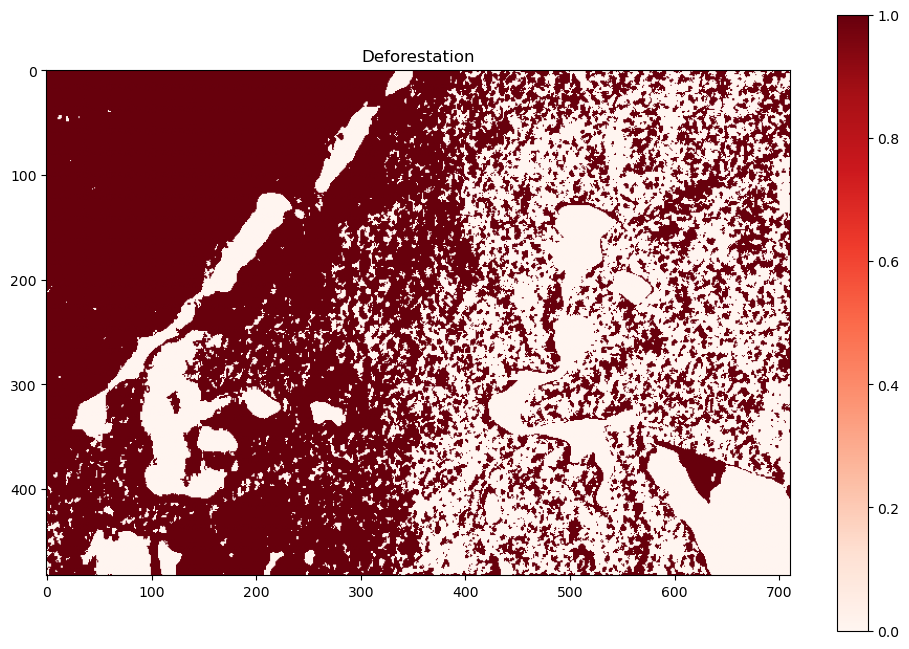

In [ ]:
# steep -2., flat 0.16 window 5
# Convert to numpy 
defor_np = geemap.ee_to_numpy(defor_mask, region=roi, scale=10)

# Display
plt.figure(figsize=(12, 8))
plt.imshow(defor_np, cmap='Reds')
plt.colorbar()
plt.title('Deforestation')
plt.show()

## Testing config

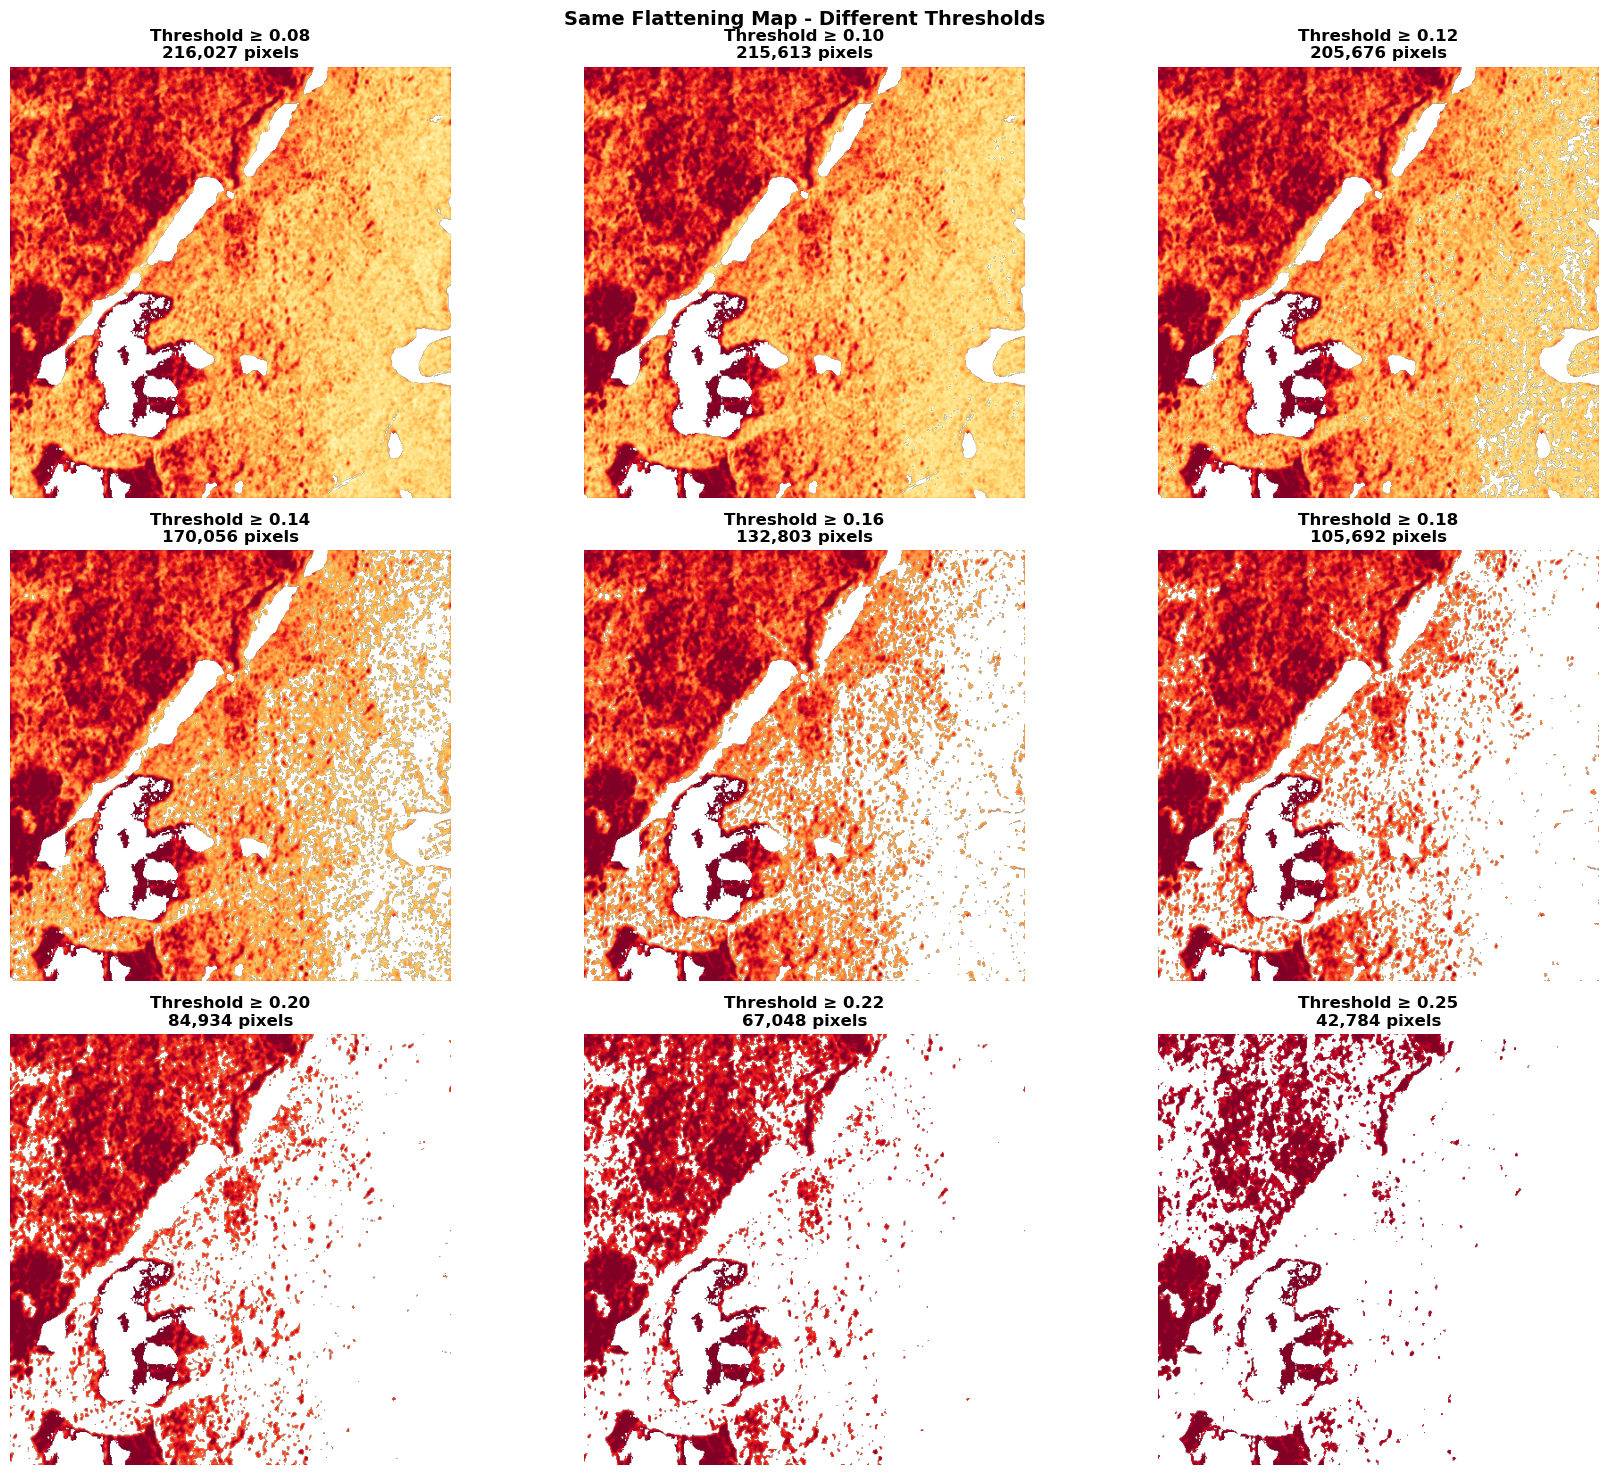

In [26]:
"""
Simply apply different thresholds to the same flattening map
"""

# Calculate flattening once
flattening = amp.divide(lower.abs()).rename('flattening')
flattening_masked = flattening.updateMask(candidate_mask).updateMask(forest_mask_gee)
flat_np = geemap.ee_to_numpy(flattening_masked, region=roi, scale=10)

# Test different thresholds
thresholds = [0.08, 0.10, 0.12, 0.14, 0.16, 0.18, 0.20, 0.22, 0.25]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, thresh in enumerate(thresholds):
    masked = np.where(flat_np >= thresh, flat_np, np.nan)
    pixel_count = np.sum(~np.isnan(masked))
    
    axes[i].imshow(masked, cmap='YlOrRd', vmin=0.08, vmax=0.30)
    axes[i].set_title(f"Threshold ≥ {thresh:.2f}\n{pixel_count:,} pixels", fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Same Flattening Map - Different Thresholds', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

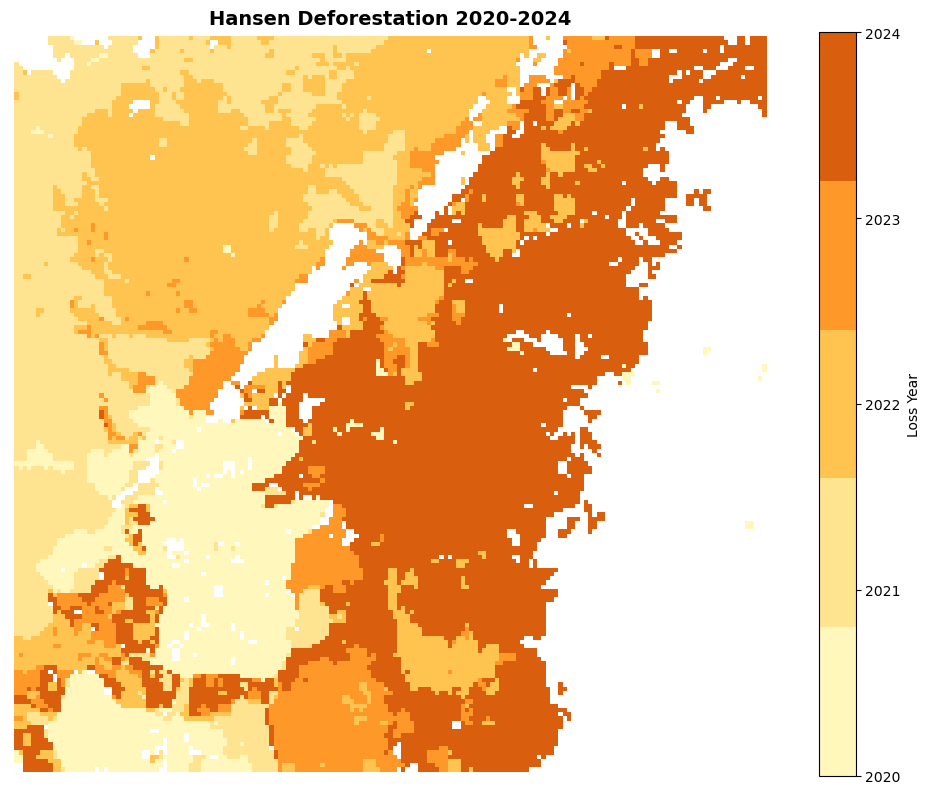

Deforested pixels (2020-2024): 23,125


In [3]:
import rasterio
from rasterio.mask import mask
from shapely.geometry import box
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Load Hansen data
hansen_path = "/home/georg/data/LEON_P6_forest-agri-change/Hansen/Hansen_GFC-2024-v1.12_lossyear_10N_030E.tif"

bbox = [30.9254932403564, 1.24946939945221, 
        30.9698562622070, 1.29278075695038]

geom = [box(*bbox)]

# Read and crop
with rasterio.open(hansen_path) as src:
    out_image, out_transform = mask(src, geom, crop=True)
    data = out_image[0]

# Keep only years 20-24
data_filtered = np.where((data >= 20) & (data <= 24), data, np.nan)

# Plot with better colors
plt.figure(figsize=(10, 8))
cmap = ListedColormap(['#fff7bc', '#fee391', '#fec44f', '#fe9929', '#d95f0e'])
im = plt.imshow(data_filtered, cmap=cmap, vmin=20, vmax=24, interpolation='nearest')
cbar = plt.colorbar(im, label='Loss Year', ticks=[20, 21, 22, 23, 24])
cbar.ax.set_yticklabels(['2020', '2021', '2022', '2023', '2024'])
plt.title('Hansen Deforestation 2020-2024', fontweight='bold', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Deforested pixels (2020-2024): {np.sum(~np.isnan(data_filtered)):,}")

# Create binary Hansen mask (any deforestation 2020-2024)
hansen_binary = (~np.isnan(data_filtered)).astype(int)

Your deforestation mask shape: (483, 711)
Your detected pixels: 124,196
Hansen shape: (174, 256)
Hansen detected pixels (2020-2024): 23,130
Resampling Hansen to match your grid...
Hansen resampled: (483, 711)

VALIDATION RESULTS
Overlap:     114,963 pixels (both agree)
Precision:   92.6% (your detections that are correct)
Recall:      64.4% (Hansen detections you captured)
F1 Score:    76.0% (overall agreement)
Extra:       9,233 pixels (you detected, Hansen didn't)
Missed:      63,459 pixels (Hansen detected, you didn't)


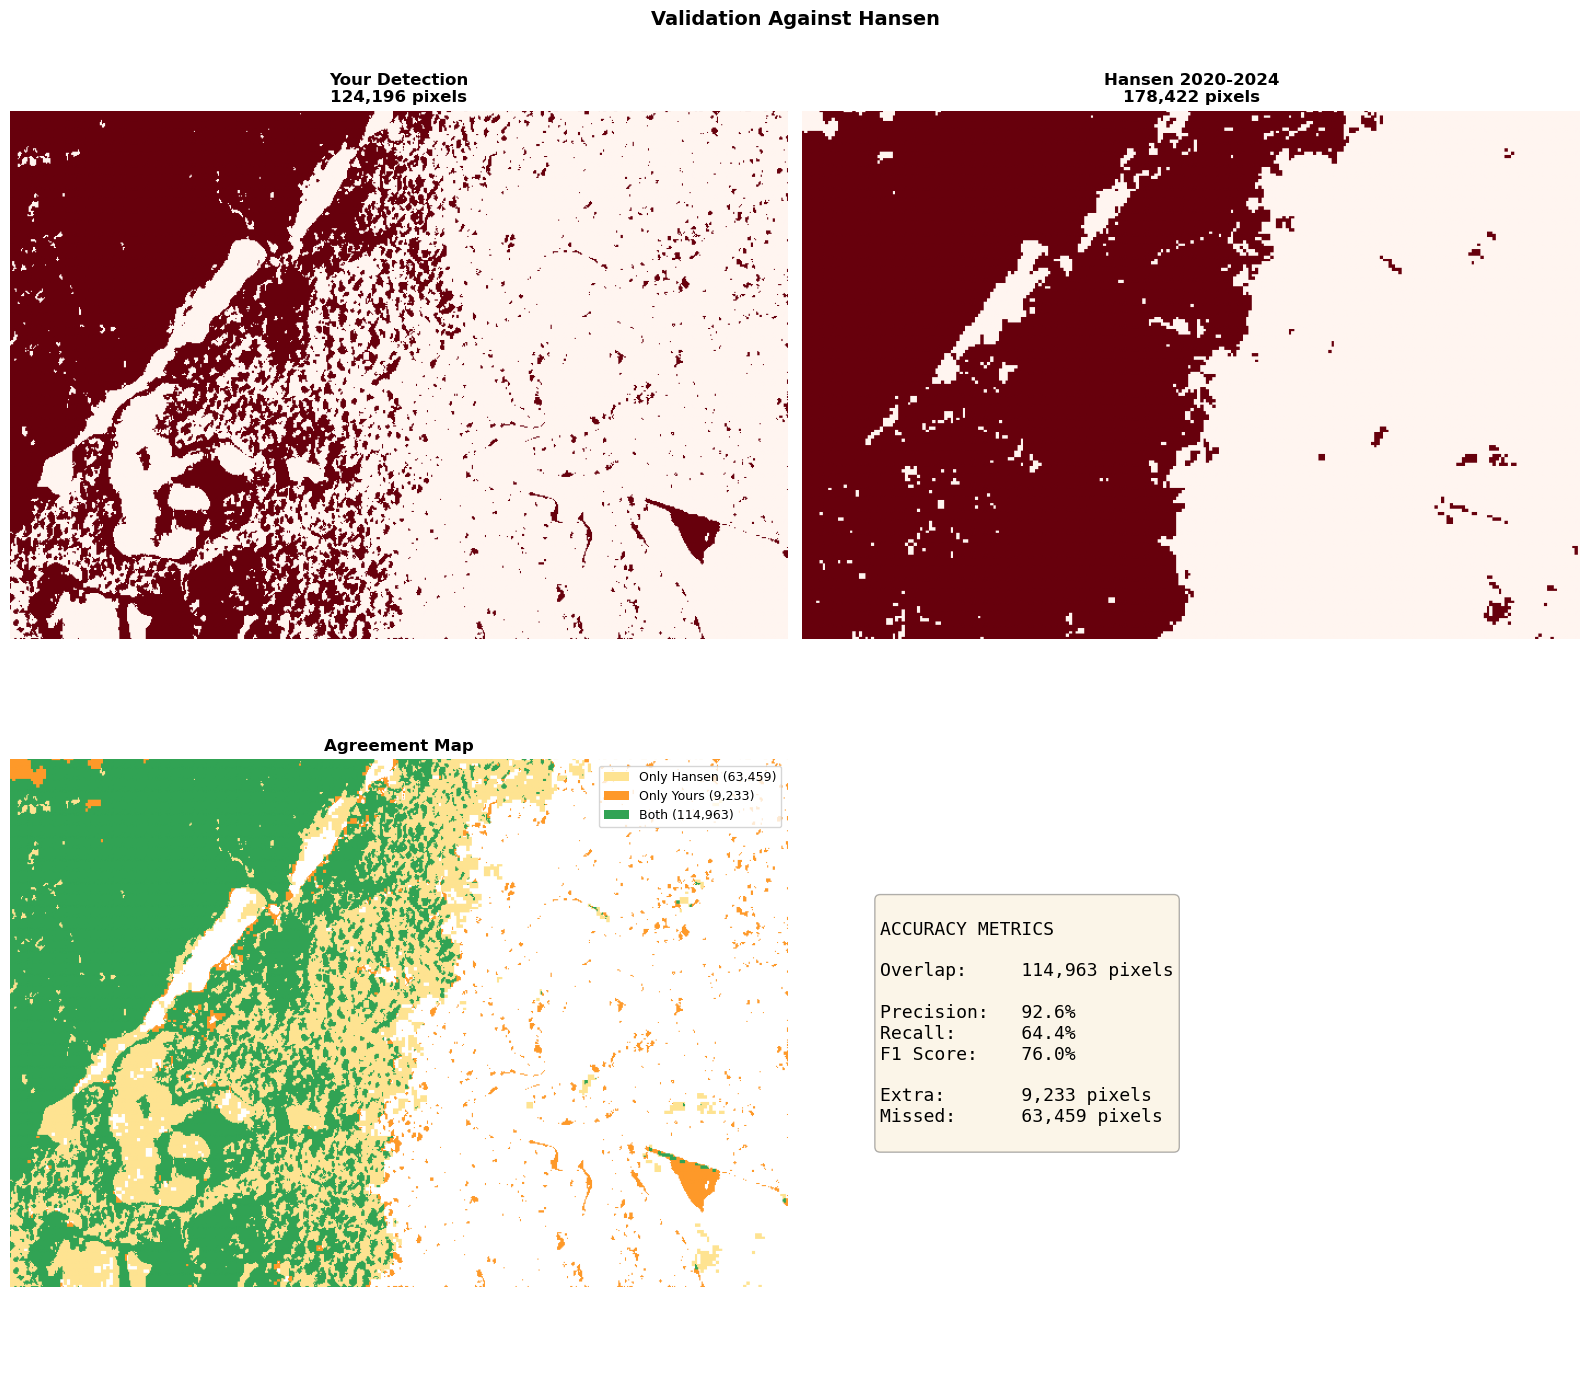

In [66]:
"""
SIMPLE HANSEN COMPARISON
=========================
Compare your current defor_mask with Hansen
"""

import rasterio
from rasterio.mask import mask
from shapely.geometry import box
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.ndimage import zoom

# ===================== LOAD YOUR CURRENT MASK =====================
# Convert your current defor_mask to numpy
current_defor = geemap.ee_to_numpy(defor_mask, region=roi, scale=10)
current_defor = np.squeeze(current_defor)  # Remove extra dimensions
print(f"Your deforestation mask shape: {current_defor.shape}")
print(f"Your detected pixels: {np.sum(current_defor == 1):,}")

# ===================== LOAD HANSEN =====================
hansen_path = "/home/georg/data/LEON_P6_forest-agri-change/Hansen/Hansen_GFC-2024-v1.12_lossyear_10N_030E.tif"
bbox = [30.9260005950927983,1.2490921020507799, 30.9897918701172017,1.2923980951309200]


with rasterio.open(hansen_path) as src:
    out_image, out_transform = mask(src, [box(*bbox)], crop=True)
    hansen_data = out_image[0]

# Filter to 2020-2024
hansen_binary = np.where((hansen_data >= 20) & (hansen_data <= 24), 1, 0)
print(f"Hansen shape: {hansen_binary.shape}")
print(f"Hansen detected pixels (2020-2024): {np.sum(hansen_binary):,}")

# ===================== MATCH GRIDS =====================
if hansen_binary.shape != current_defor.shape:
    print(f"Resampling Hansen to match your grid...")
    zoom_factors = (current_defor.shape[0] / hansen_binary.shape[0], 
                    current_defor.shape[1] / hansen_binary.shape[1])
    hansen_binary = zoom(hansen_binary, zoom_factors, order=0)
    print(f"Hansen resampled: {hansen_binary.shape}")

# ===================== CALCULATE METRICS =====================
pred = np.nan_to_num(current_defor, nan=0).astype(int)
hansen = hansen_binary.astype(int)

true_positive = np.sum((pred == 1) & (hansen == 1))
false_positive = np.sum((pred == 1) & (hansen == 0))
false_negative = np.sum((pred == 0) & (hansen == 1))

precision = true_positive / (true_positive + false_positive) * 100 if (true_positive + false_positive) > 0 else 0
recall = true_positive / (true_positive + false_negative) * 100 if (true_positive + false_negative) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\n" + "="*60)
print("VALIDATION RESULTS")
print("="*60)
print(f"Overlap:     {true_positive:,} pixels (both agree)")
print(f"Precision:   {precision:.1f}% (your detections that are correct)")
print(f"Recall:      {recall:.1f}% (Hansen detections you captured)")
print(f"F1 Score:    {f1:.1f}% (overall agreement)")
print(f"Extra:       {false_positive:,} pixels (you detected, Hansen didn't)")
print(f"Missed:      {false_negative:,} pixels (Hansen detected, you didn't)")

# ===================== VISUALIZE =====================
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Your detection
axes[0, 0].imshow(pred, cmap='Reds', vmin=0, vmax=1)
axes[0, 0].set_title(f'Your Detection\n{np.sum(pred):,} pixels', 
                     fontweight='bold', fontsize=12)
axes[0, 0].axis('off')

# 2. Hansen
axes[0, 1].imshow(hansen, cmap='Reds', vmin=0, vmax=1)
axes[0, 1].set_title(f'Hansen 2020-2024\n{np.sum(hansen):,} pixels', 
                     fontweight='bold', fontsize=12)
axes[0, 1].axis('off')

# 3. Overlap map
overlap = np.zeros_like(hansen, dtype=float)
overlap[(pred == 1) & (hansen == 1)] = 3  # Both
overlap[(pred == 1) & (hansen == 0)] = 2  # Only yours
overlap[(pred == 0) & (hansen == 1)] = 1  # Only Hansen

cmap = ListedColormap(['white', '#fee391', '#fe9929', '#31a354'])
axes[1, 0].imshow(overlap, cmap=cmap, vmin=0, vmax=3)
axes[1, 0].set_title('Agreement Map', fontweight='bold', fontsize=12)
axes[1, 0].axis('off')

legend = [
    Patch(facecolor='#fee391', label=f'Only Hansen ({false_negative:,})'),
    Patch(facecolor='#fe9929', label=f'Only Yours ({false_positive:,})'),
    Patch(facecolor='#31a354', label=f'Both ({true_positive:,})')
]
axes[1, 0].legend(handles=legend, loc='upper right', fontsize=9)

# 4. Metrics
axes[1, 1].axis('off')
metrics_text = f"""
ACCURACY METRICS

Overlap:     {true_positive:,} pixels

Precision:   {precision:.1f}%
Recall:      {recall:.1f}%
F1 Score:    {f1:.1f}%

Extra:       {false_positive:,} pixels
Missed:      {false_negative:,} pixels
"""
axes[1, 1].text(0.1, 0.5, metrics_text, fontsize=13, 
                verticalalignment='center', family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Validation Against Hansen', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## ---Vis--

In [25]:
"""
Visualize Results (Run AFTER step3)
====================================
"""

import ee
import geemap

print("Creating visualization...")

# ===================== CREATE DEFOR MASK (if not already created) =====================
if 'defor_mask' not in dir():
    print("Creating deforestation mask...")
    # FLAT_THRESH = 0.14
    defor_mask = candidate_mask \
        .And(flattening.gte(FLAT_THRESH)) \
        .rename('deforested') \
        .updateMask(forest_mask_gee)
    
    n_deforested = defor_mask.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=10,
        maxPixels=1e10
    ).getInfo().get('deforested', 0)
    
    print(f"✓ Deforested pixels: {n_deforested}")

# ===================== CREATE MAP =====================
Map = geemap.Map()
Map.centerObject(roi, 13)

# ===================== ADD LAYERS =====================

# 1. ROI boundary
Map.addLayer(roi, {'color': 'blue'}, 'ROI', True)

# 2. S1 median composite (use the VH collection)
s1_median = s1_vh.median()
Map.addLayer(
    s1_median, 
    {'min': -25, 'max': -10, 'palette': ['black', 'white']}, 
    'S1 VH median',
    True
)

# 3. Forest mask
Map.addLayer(
    forest_mask_gee, 
    {'palette': ['darkgreen']}, 
    'Forest mask', 
    False
)

# 4. Temporal variability (std dev)
Map.addLayer(
    std_dev.updateMask(forest_mask_gee),
    {'min': 0, 'max': 3, 'palette': ['blue', 'yellow', 'red']},
    'Temporal Std Dev',
    False
)

# 5. Candidate pixels
Map.addLayer(
    candidate_mask.updateMask(forest_mask_gee).selfMask(),
    {'palette': ['orange']},
    'Candidates (high variability)',
    False
)

# 6. Flattening metric
Map.addLayer(
    flattening.updateMask(candidate_mask).updateMask(forest_mask_gee),
    {'min': 0.05, 'max': 0.25, 'palette': ['yellow', 'orange', 'red']},
    'Flattening',
    False
)

# 7. Final deforestation mask
Map.addLayer(
    defor_mask.selfMask(),
    {'palette': ['red']},
    '🔴 DEFORESTATION',
    True
)

# 8. Deforestation date (as year)
Map.addLayer(
    defor_year.updateMask(defor_mask),
    {'min': 2024, 'max': 2024.5, 'palette': ['yellow', 'orange', 'red']},
    'Deforestation date',
    True
)

print("\n✓ Map created!")
print("\n📊 Layers (toggle in map controls):")
print("  • ROI - Your study area")
print("  • S1 VH median - SAR background")
print("  • Forest mask - 2020 forest extent")
print("  • Temporal Std Dev - Variability")
print("  • Candidates - High variability pixels")
print("  • Flattening - Signal change strength")
print("  • 🔴 DEFORESTATION - Final detection")
print("  • Deforestation date - When it occurred")

print("\n💡 Tip: Click layers in map to toggle visibility")

# Display the map
Map

Creating visualization...


AttributeError: 'float' object has no attribute 'updateMask'

## Export

In [31]:
# Export deforestation date year
print("\n💾 Exporting to Google Drive...")

version = "v5"  # Update version as needed

export_image = defor_year.updateMask(defor_mask).toFloat()

task = ee.batch.Export.image.toDrive(
    image=export_image,
    description=f'deforestation_dates_bugoma_{version}_f02',
    scale=10,
    region=roi,
    maxPixels=1e10,
    fileFormat='GeoTIFF',
    crs='EPSG:32636'
)

task.start()
print("✅ Export started!")
print("   Check Google Drive: deforestation_dates_bugoma_v2.tif")


💾 Exporting to Google Drive...
✅ Export started!
   Check Google Drive: deforestation_dates_bugoma_v2.tif


In [ ]:
"""
Export Output Maps
==================
"""

version = "v5"  # Update version as needed
flatten = "f02"

print("="*60)
print(f"Exporting Output Maps {version} {flatten}")
print("="*60)

# ===================== 1. TEMPORAL VARIABILITY MAP (from Step 2) =====================
# print("\n1. Exporting temporal variability map...")
# task1 = ee.batch.Export.image.toDrive(
#     image=std_dev.updateMask(forest_mask_gee).toFloat(),
#     description=f'temporal_variability_bugoma_{version}',
#     scale=10,
#     region=roi,
#     maxPixels=1e10,
#     fileFormat='GeoTIFF',
#     crs='EPSG:32636'
# )
# task1.start()
# print(f"   ✅ Export started: temporal_variability_bugoma_{version}.tif")

# # ===================== 2. FLATTENING PARAMETER MAP (from Step 3) =====================
# print("\n2. Exporting flattening parameter map...")
# task2 = ee.batch.Export.image.toDrive(
#     image=flattening.updateMask(candidate_mask).updateMask(forest_mask_gee).toFloat(),
#     description=f'flattening_parameter_bugoma_{version}',
#     scale=10,
#     region=roi,
#     maxPixels=1e10,
#     fileFormat='GeoTIFF',
#     crs='EPSG:32636'
# )
# task2.start()
# print(f"   ✅ Export started: flattening_parameter_bugoma_{version}.tif")

# ===================== 3. DEFORESTATION DATES MAP =====================
# print("\n3. Exporting deforestation dates map...")
# task3 = ee.batch.Export.image.toDrive(
#     image=defor_year.updateMask(defor_mask).toFloat(),
#     description=f'deforestation_dates_bugoma_{version}',
#     scale=10,
#     region=roi,
#     maxPixels=1e10,
#     fileFormat='GeoTIFF',
#     crs='EPSG:32636'
# )
# task3.start()
# print(f"   ✅ Export started: deforestation_dates_bugoma_{version}.tif")

# Export deforestation date year
# print("\n3. Exporting deforestation dates map...")


# ===================== 4. DEFORESTATION MASK (BINARY) =====================
print("\n4. Exporting deforestation mask...")
task4 = ee.batch.Export.image.toDrive(
    image=defor_mask.toByte(),
    description=f'deforestation_mask_bugoma_{version}_{flatten}',
    scale=10,
    region=roi,
    maxPixels=1e10,
    fileFormat='GeoTIFF',
    crs='EPSG:32636'
)
task4.start()
print(f"   ✅ Export started: deforestation_mask_bugoma_{version}_f02.tif")

print("\n" + "="*60)
print("✅ All exports started! 📂 Check Google Drive")
print("="*60)

Exporting Output Maps v5

1. Exporting temporal variability map...
   ✅ Export started: temporal_variability_bugoma_v5.tif

2. Exporting flattening parameter map...
   ✅ Export started: flattening_parameter_bugoma_v5.tif

4. Exporting deforestation mask...
   ✅ Export started: deforestation_mask_bugoma_v5_f02.tif

✅ All exports started! 📂 Check Google Drive


In [13]:
# Get boundaries at ROI center
bounds = roi.bounds().getInfo()['coordinates'][0]
center = ee.Geometry.Point([(bounds[0][0] + bounds[2][0])/2, 
                            (bounds[0][1] + bounds[2][1])/2])

upper = p95.reduceRegion(ee.Reducer.first(), center, 10).getInfo()['p95']
lower = p05.reduceRegion(ee.Reducer.first(), center, 10).getInfo()['p05']

print(f"Upper (forest): {upper:.2f} dB")
print(f"Lower (deforested): {lower:.2f} dB")

Upper (forest): -13.67 dB
Lower (deforested): -16.30 dB


## ---Timerseries---

Plotting time series for 5 points
Center point: [30.94767, 1.27113]
Random 1:    [30.95386, 1.25055]
Random 2:    [30.93769, 1.25914]
Random 3:    [30.95817, 1.27878]
Random 4:    [30.96507, 1.25323]

Extracting time series...
  Extracting CENTER...
  Extracting Random 1...
  Extracting Random 2...
  Extracting Random 3...
  Extracting Random 4...
✓ Extracted 5 valid time series

Creating plots...


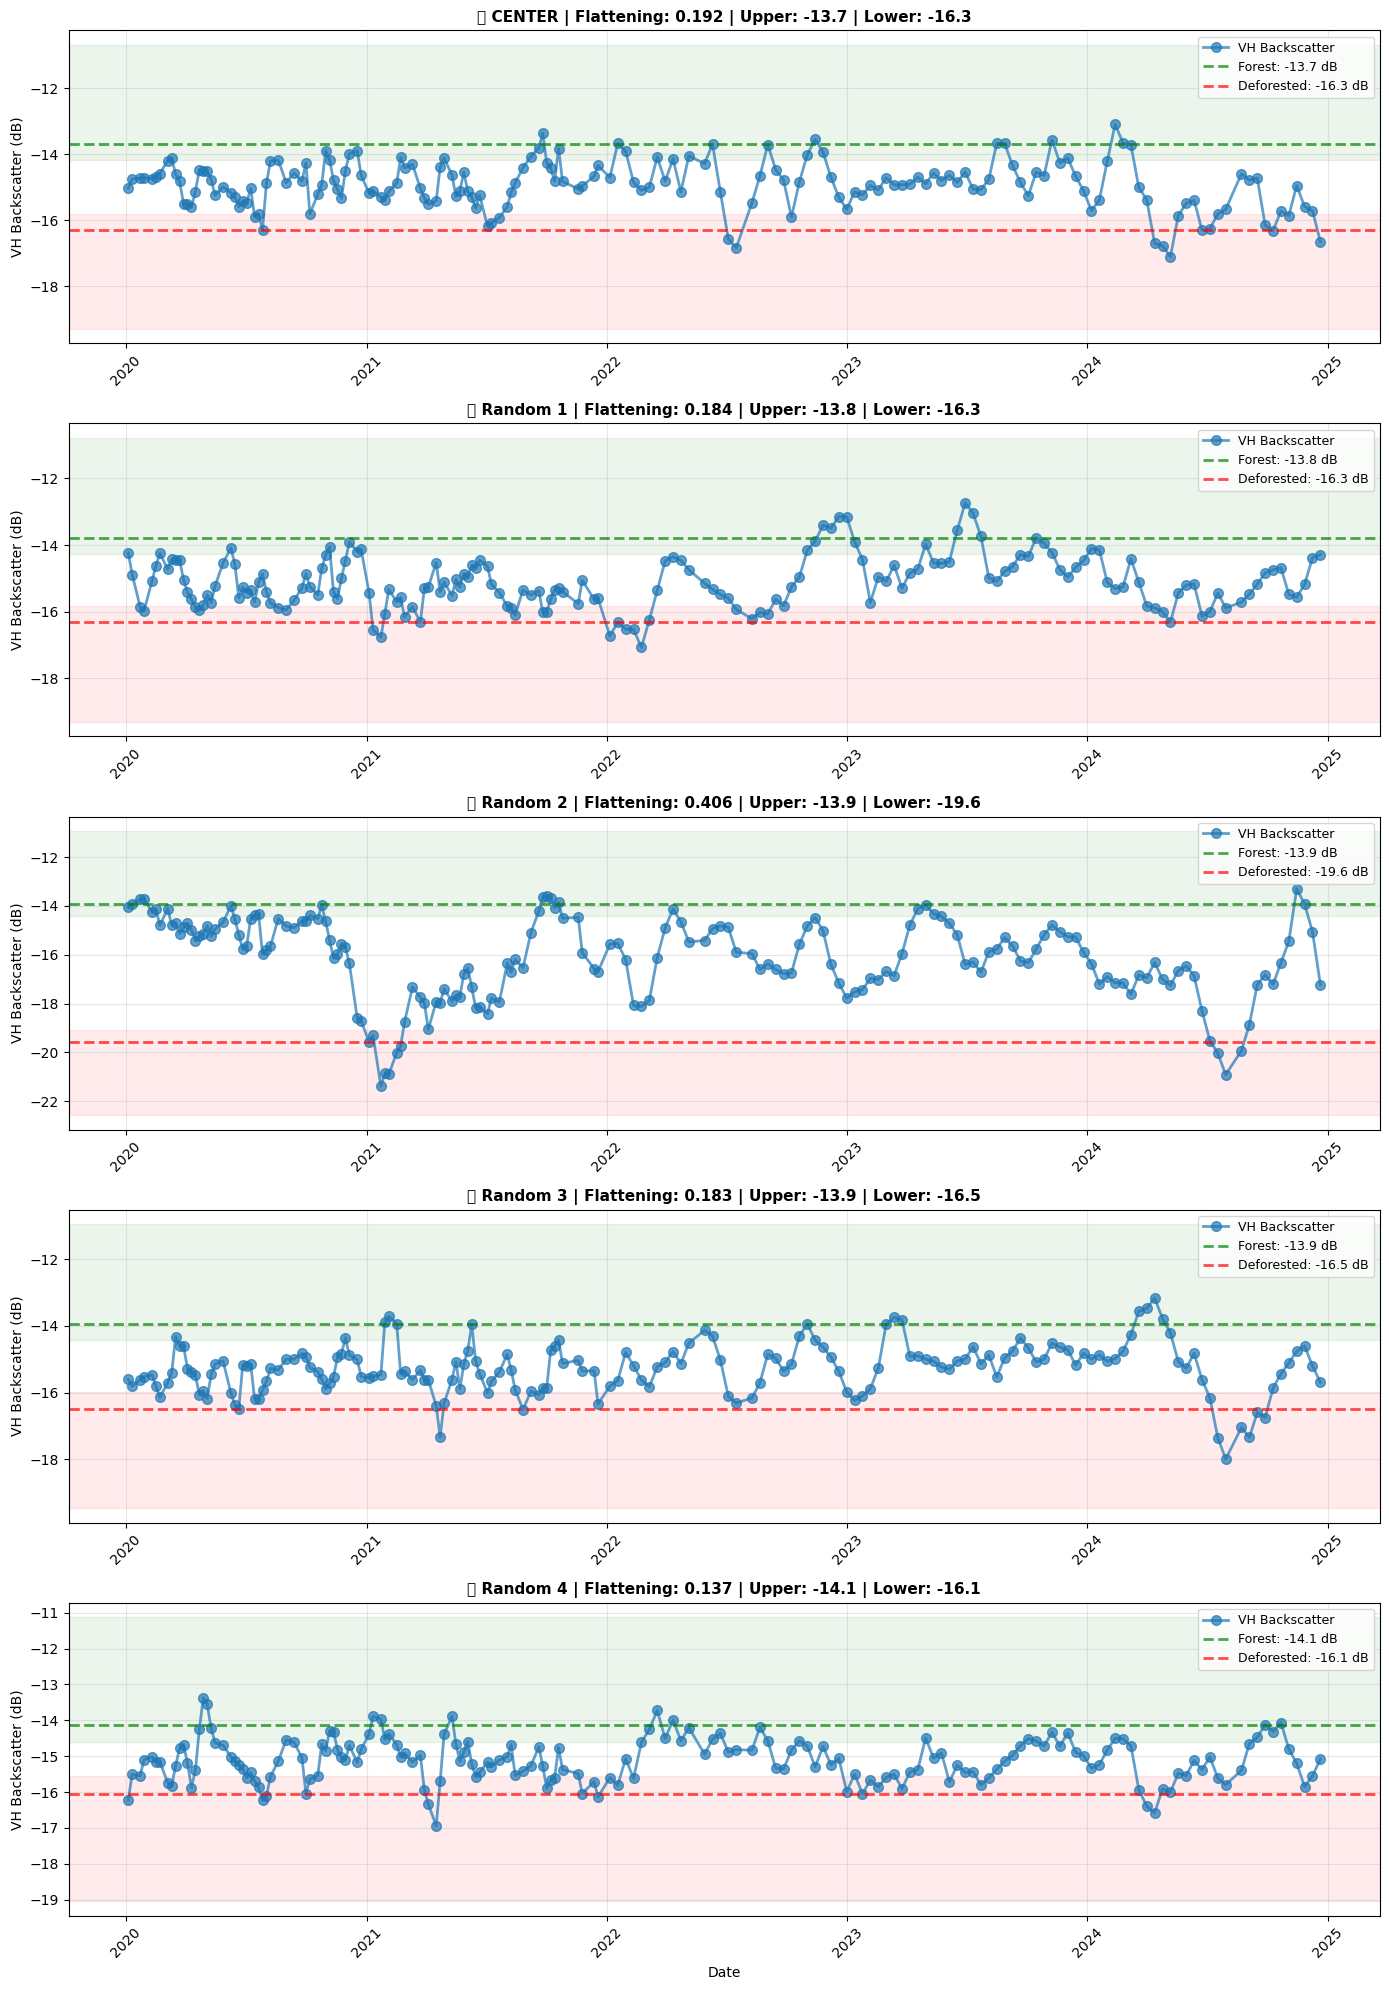


✓ Plots complete!

SUMMARY

CENTER:
  🔴 CHANGED
  Upper: -13.67 dB | Lower: -16.30 dB
  Flattening: 0.192 ✅
  VH range: -17.10 to -13.09 dB

Random 1:
  🔴 CHANGED
  Upper: -13.78 dB | Lower: -16.31 dB
  Flattening: 0.184 ✅
  VH range: -17.07 to -12.73 dB

Random 2:
  🔴 CHANGED
  Upper: -13.92 dB | Lower: -19.57 dB
  Flattening: 0.406 ✅
  VH range: -21.39 to -13.30 dB

Random 3:
  🔴 CHANGED
  Upper: -13.93 dB | Lower: -16.48 dB
  Flattening: 0.183 ✅
  VH range: -18.00 to -13.16 dB

Random 4:
  🔴 CHANGED
  Upper: -14.12 dB | Lower: -16.05 dB
  Flattening: 0.137 ⚠️
  VH range: -16.94 to -13.38 dB

💡 Interpretation:
  🟢 STABLE = Backscatter stays near forest level
  🔴 CHANGED = Backscatter drops toward deforested level
  ✅ Flattening ≥ 0.14 = Strong enough for detection


In [34]:
"""
Time Series: 1 Center + 4 Random Points
========================================
Compare deforestation signals across your ROI
Works with smoothed or unsmoothed data
"""

import matplotlib.pyplot as plt
from datetime import datetime
import random

print("="*60)
print("Plotting time series for 5 points")
print("="*60)

# ===================== SELECT COLLECTION =====================
# Use the same filtered data as Step 2 & 3
collection_to_plot = s1_multitemporal  # s1_collection

# ===================== DEFINE POINTS =====================
# 1. Center point (fixed)
bounds = roi.bounds().getInfo()['coordinates'][0]
center_lon = (bounds[0][0] + bounds[2][0]) / 2
center_lat = (bounds[0][1] + bounds[2][1]) / 2
center_point = ee.Geometry.Point([center_lon, center_lat])

print(f"Center point: [{center_lon:.5f}, {center_lat:.5f}]")

# 2. Four random points
min_lon, max_lon = bounds[0][0], bounds[1][0]
min_lat, max_lat = bounds[0][1], bounds[2][1]

random.seed(42)
random_points = []
for i in range(4):
    rand_lon = random.uniform(min_lon, max_lon)
    rand_lat = random.uniform(min_lat, max_lat)
    random_points.append(ee.Geometry.Point([rand_lon, rand_lat]))
    print(f"Random {i+1}:    [{rand_lon:.5f}, {rand_lat:.5f}]")

all_points = [center_point] + random_points
point_names = ['CENTER'] + [f'Random {i+1}' for i in range(4)]

# ===================== EXTRACT TIME SERIES =====================
print("\nExtracting time series...")

def extract_timeseries(point):
    """Extract VH time series for a point"""
    try:
        values = collection_to_plot.getRegion(point, 10).getInfo()
        header = values[0]
        data = values[1:]
        
        if len(data) == 0:
            return None, None, None, None
        
        time_idx = header.index('time')
        vh_idx = [i for i, name in enumerate(header) if 'VH' in str(name)][0]
        
        # Filter out rows with None values (FIXED)
        valid_data = [(row[time_idx], row[vh_idx]) for row in data 
                      if row[time_idx] is not None and row[vh_idx] is not None]
        
        if len(valid_data) == 0:
            return None, None, None, None
        
        times, vh_values = zip(*valid_data)
        dates = [datetime.fromtimestamp(t/1000) for t in times]
        
        # Get boundaries at this point
        upper_result = p95.reduceRegion(ee.Reducer.first(), point, 10).getInfo()
        lower_result = p05.reduceRegion(ee.Reducer.first(), point, 10).getInfo()
        
        upper = upper_result.get('p95') if upper_result else None
        lower = lower_result.get('p05') if lower_result else None
        
        if upper is None or lower is None:
            return None, None, None, None
        
        return dates, list(vh_values), upper, lower
    except Exception as e:
        print(f"  ⚠️  Error extracting: {e}")
        return None, None, None, None

# Extract all time series
timeseries_data = []
valid_point_names = []
for i, point in enumerate(all_points):
    print(f"  Extracting {point_names[i]}...")
    dates, vh, upper, lower = extract_timeseries(point)
    if dates is not None and vh is not None:
        timeseries_data.append((dates, vh, upper, lower))
        valid_point_names.append(point_names[i])
    else:
        print(f"    ⚠️  Skipped (no valid data)")

n_valid = len(timeseries_data)
print(f"✓ Extracted {n_valid} valid time series")

if n_valid == 0:
    print("\n❌ No valid points found!")
    print("Try adjusting your ROI or check if data exists")
    import sys
    sys.exit()

# ===================== PLOT =====================
print("\nCreating plots...")

fig, axes = plt.subplots(n_valid, 1, figsize=(14, 4*n_valid))
if n_valid == 1:
    axes = [axes]

for idx, (ax, (dates, vh, upper, lower), name) in enumerate(zip(axes, timeseries_data, valid_point_names)):
    
    flattening = abs(upper - lower) / abs(upper)
    
    ax.plot(dates, vh, 'o-', linewidth=2, markersize=7, alpha=0.7, label='VH Backscatter')
    
    ax.axhline(upper, color='green', linestyle='--', linewidth=2, alpha=0.7, 
               label=f'Forest: {upper:.1f} dB')
    ax.axhline(lower, color='red', linestyle='--', linewidth=2, alpha=0.7, 
               label=f'Deforested: {lower:.1f} dB')
    
    ax.axhspan(upper-0.5, upper+3, alpha=0.08, color='green')
    ax.axhspan(lower-3, lower+0.5, alpha=0.08, color='red')
    
    midpoint = (upper + lower) / 2
    changed = any(v < midpoint for v in vh)
    change_emoji = "🔴" if changed else "🟢"
    
    ax.set_ylabel('VH Backscatter (dB)', fontsize=10)
    title = f'{change_emoji} {name} | Flattening: {flattening:.3f} | Upper: {upper:.1f} | Lower: {lower:.1f}'
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    if idx == n_valid - 1:
        ax.set_xlabel('Date', fontsize=10)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✓ Plots complete!")

# ===================== SUMMARY =====================
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

for i, (dates, vh, upper, lower) in enumerate(timeseries_data):
    name = valid_point_names[i]
    flattening = abs(upper - lower) / abs(upper)
    
    midpoint = (upper + lower) / 2
    min_vh = min(vh)
    max_vh = max(vh)
    
    dropped = min_vh < midpoint
    status = "🔴 CHANGED" if dropped else "🟢 STABLE"
    
    print(f"\n{name}:")
    print(f"  {status}")
    print(f"  Upper: {upper:.2f} dB | Lower: {lower:.2f} dB")
    print(f"  Flattening: {flattening:.3f} {'✅' if flattening >= 0.14 else '⚠️'}")
    print(f"  VH range: {min_vh:.2f} to {max_vh:.2f} dB")

print("\n" + "="*60)
print("💡 Interpretation:")
print("  🟢 STABLE = Backscatter stays near forest level")
print("  🔴 CHANGED = Backscatter drops toward deforested level")
print("  ✅ Flattening ≥ 0.14 = Strong enough for detection")
print("="*60)

Plotting time series for 5 points
Center point: [30.94767, 1.27113]
Random 1:    [30.95386, 1.25055]
Random 2:    [30.93769, 1.25914]
Random 3:    [30.95817, 1.27878]
Random 4:    [30.96507, 1.25323]

Extracting time series...
  Extracting CENTER...
  Extracting Random 1...
  Extracting Random 2...
  Extracting Random 3...
  Extracting Random 4...
✓ Extracted 5 valid time series

Creating plots...


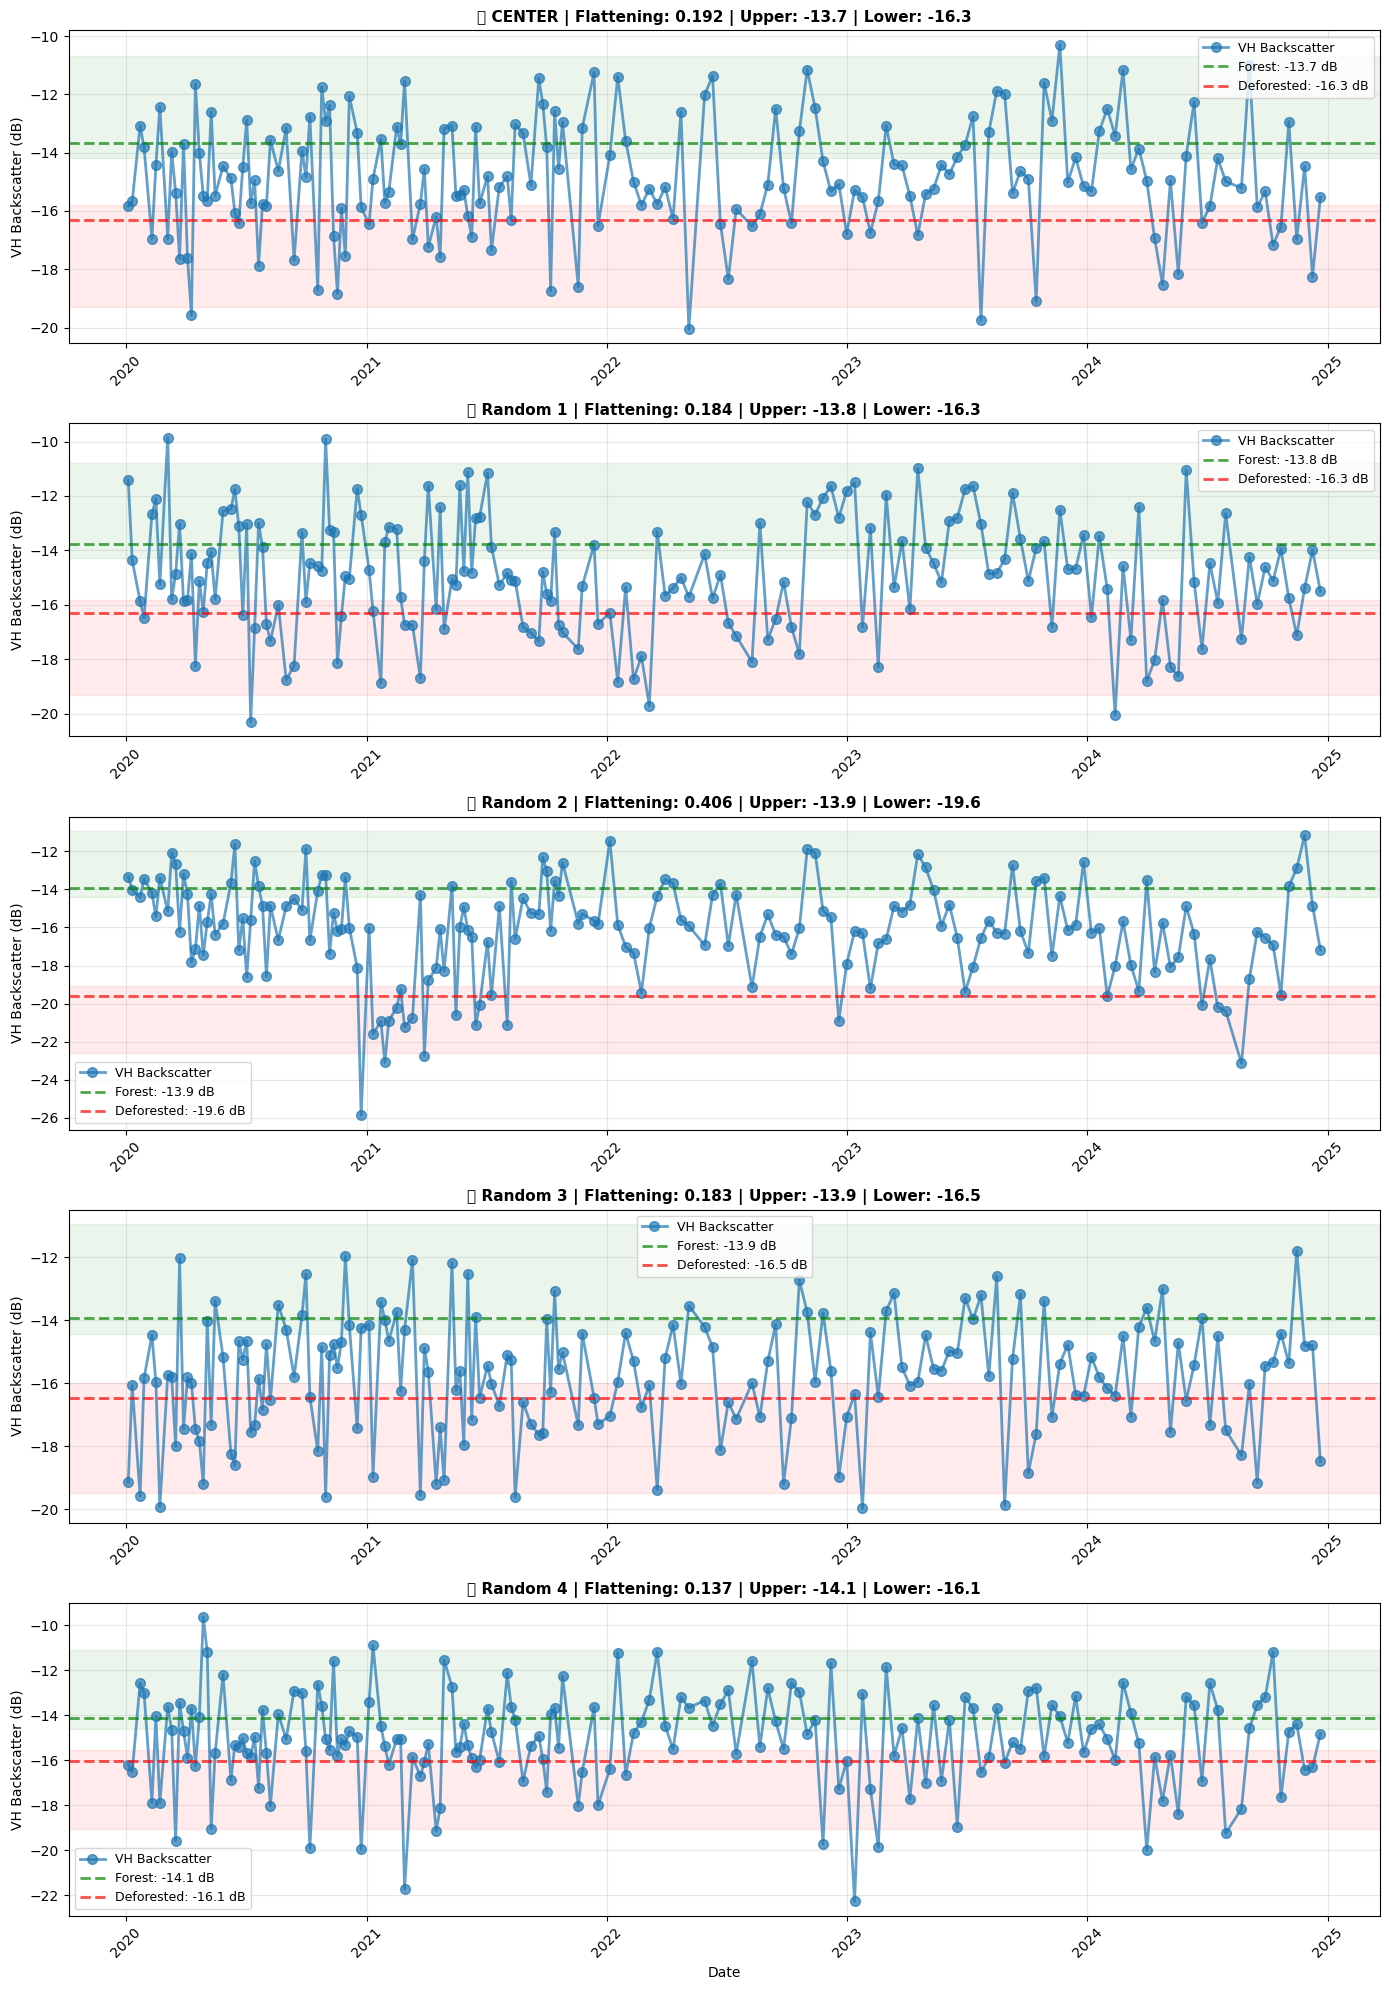


✓ Plots complete!

SUMMARY

CENTER:
  🔴 CHANGED
  Upper: -13.67 dB | Lower: -16.30 dB
  Flattening: 0.192 ✅
  VH range: -20.05 to -10.29 dB

Random 1:
  🔴 CHANGED
  Upper: -13.78 dB | Lower: -16.31 dB
  Flattening: 0.184 ✅
  VH range: -20.32 to -9.86 dB

Random 2:
  🔴 CHANGED
  Upper: -13.92 dB | Lower: -19.57 dB
  Flattening: 0.406 ✅
  VH range: -25.86 to -11.16 dB

Random 3:
  🔴 CHANGED
  Upper: -13.93 dB | Lower: -16.48 dB
  Flattening: 0.183 ✅
  VH range: -19.98 to -11.79 dB

Random 4:
  🔴 CHANGED
  Upper: -14.12 dB | Lower: -16.05 dB
  Flattening: 0.137 ⚠️
  VH range: -22.28 to -9.64 dB

💡 Interpretation:
  🟢 STABLE = Backscatter stays near forest level
  🔴 CHANGED = Backscatter drops toward deforested level
  ✅ Flattening ≥ 0.14 = Strong enough for detection


In [15]:
"""
Time Series: 1 Center + 4 Random Points
========================================
Compare deforestation signals across your ROI
Works with smoothed or unsmoothed data
"""

import matplotlib.pyplot as plt
from datetime import datetime
import random

print("="*60)
print("Plotting time series for 5 points")
print("="*60)

# ===================== SELECT COLLECTION =====================
# Use the same filtered data as Step 2 & 3
collection_to_plot = s1_collection

# ===================== DEFINE POINTS =====================
# 1. Center point (fixed)
bounds = roi.bounds().getInfo()['coordinates'][0]
center_lon = (bounds[0][0] + bounds[2][0]) / 2
center_lat = (bounds[0][1] + bounds[2][1]) / 2
center_point = ee.Geometry.Point([center_lon, center_lat])

print(f"Center point: [{center_lon:.5f}, {center_lat:.5f}]")

# 2. Four random points
min_lon, max_lon = bounds[0][0], bounds[1][0]
min_lat, max_lat = bounds[0][1], bounds[2][1]

random.seed(42)
random_points = []
for i in range(4):
    rand_lon = random.uniform(min_lon, max_lon)
    rand_lat = random.uniform(min_lat, max_lat)
    random_points.append(ee.Geometry.Point([rand_lon, rand_lat]))
    print(f"Random {i+1}:    [{rand_lon:.5f}, {rand_lat:.5f}]")

all_points = [center_point] + random_points
point_names = ['CENTER'] + [f'Random {i+1}' for i in range(4)]

# ===================== EXTRACT TIME SERIES =====================
print("\nExtracting time series...")

def extract_timeseries(point):
    """Extract VH time series for a point"""
    try:
        values = collection_to_plot.getRegion(point, 10).getInfo()
        header = values[0]
        data = values[1:]
        
        if len(data) == 0:
            return None, None, None, None
        
        time_idx = header.index('time')
        vh_idx = [i for i, name in enumerate(header) if 'VH' in str(name)][0]
        
        # Filter out rows with None values (FIXED)
        valid_data = [(row[time_idx], row[vh_idx]) for row in data 
                      if row[time_idx] is not None and row[vh_idx] is not None]
        
        if len(valid_data) == 0:
            return None, None, None, None
        
        times, vh_values = zip(*valid_data)
        dates = [datetime.fromtimestamp(t/1000) for t in times]
        
        # Get boundaries at this point
        upper_result = p95.reduceRegion(ee.Reducer.first(), point, 10).getInfo()
        lower_result = p05.reduceRegion(ee.Reducer.first(), point, 10).getInfo()
        
        upper = upper_result.get('p95') if upper_result else None
        lower = lower_result.get('p05') if lower_result else None
        
        if upper is None or lower is None:
            return None, None, None, None
        
        return dates, list(vh_values), upper, lower
    except Exception as e:
        print(f"  ⚠️  Error extracting: {e}")
        return None, None, None, None

# Extract all time series
timeseries_data = []
valid_point_names = []
for i, point in enumerate(all_points):
    print(f"  Extracting {point_names[i]}...")
    dates, vh, upper, lower = extract_timeseries(point)
    if dates is not None and vh is not None:
        timeseries_data.append((dates, vh, upper, lower))
        valid_point_names.append(point_names[i])
    else:
        print(f"    ⚠️  Skipped (no valid data)")

n_valid = len(timeseries_data)
print(f"✓ Extracted {n_valid} valid time series")

if n_valid == 0:
    print("\n❌ No valid points found!")
    print("Try adjusting your ROI or check if data exists")
    import sys
    sys.exit()

# ===================== PLOT =====================
print("\nCreating plots...")

fig, axes = plt.subplots(n_valid, 1, figsize=(14, 4*n_valid))
if n_valid == 1:
    axes = [axes]

for idx, (ax, (dates, vh, upper, lower), name) in enumerate(zip(axes, timeseries_data, valid_point_names)):
    
    flattening = abs(upper - lower) / abs(upper)
    
    ax.plot(dates, vh, 'o-', linewidth=2, markersize=7, alpha=0.7, label='VH Backscatter')
    
    ax.axhline(upper, color='green', linestyle='--', linewidth=2, alpha=0.7, 
               label=f'Forest: {upper:.1f} dB')
    ax.axhline(lower, color='red', linestyle='--', linewidth=2, alpha=0.7, 
               label=f'Deforested: {lower:.1f} dB')
    
    ax.axhspan(upper-0.5, upper+3, alpha=0.08, color='green')
    ax.axhspan(lower-3, lower+0.5, alpha=0.08, color='red')
    
    midpoint = (upper + lower) / 2
    changed = any(v < midpoint for v in vh)
    change_emoji = "🔴" if changed else "🟢"
    
    ax.set_ylabel('VH Backscatter (dB)', fontsize=10)
    title = f'{change_emoji} {name} | Flattening: {flattening:.3f} | Upper: {upper:.1f} | Lower: {lower:.1f}'
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    if idx == n_valid - 1:
        ax.set_xlabel('Date', fontsize=10)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✓ Plots complete!")

# ===================== SUMMARY =====================
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

for i, (dates, vh, upper, lower) in enumerate(timeseries_data):
    name = valid_point_names[i]
    flattening = abs(upper - lower) / abs(upper)
    
    midpoint = (upper + lower) / 2
    min_vh = min(vh)
    max_vh = max(vh)
    
    dropped = min_vh < midpoint
    status = "🔴 CHANGED" if dropped else "🟢 STABLE"
    
    print(f"\n{name}:")
    print(f"  {status}")
    print(f"  Upper: {upper:.2f} dB | Lower: {lower:.2f} dB")
    print(f"  Flattening: {flattening:.3f} {'✅' if flattening >= 0.14 else '⚠️'}")
    print(f"  VH range: {min_vh:.2f} to {max_vh:.2f} dB")

print("\n" + "="*60)
print("💡 Interpretation:")
print("  🟢 STABLE = Backscatter stays near forest level")
print("  🔴 CHANGED = Backscatter drops toward deforested level")
print("  ✅ Flattening ≥ 0.14 = Strong enough for detection")
print("="*60)

Plotting time series for ROI center...
Point: [30.94767, 1.27113]
Extracting VH values...
✓ Got 179 observations
Upper boundary (forest): -13.67 dB
Lower boundary (deforested): -16.30 dB


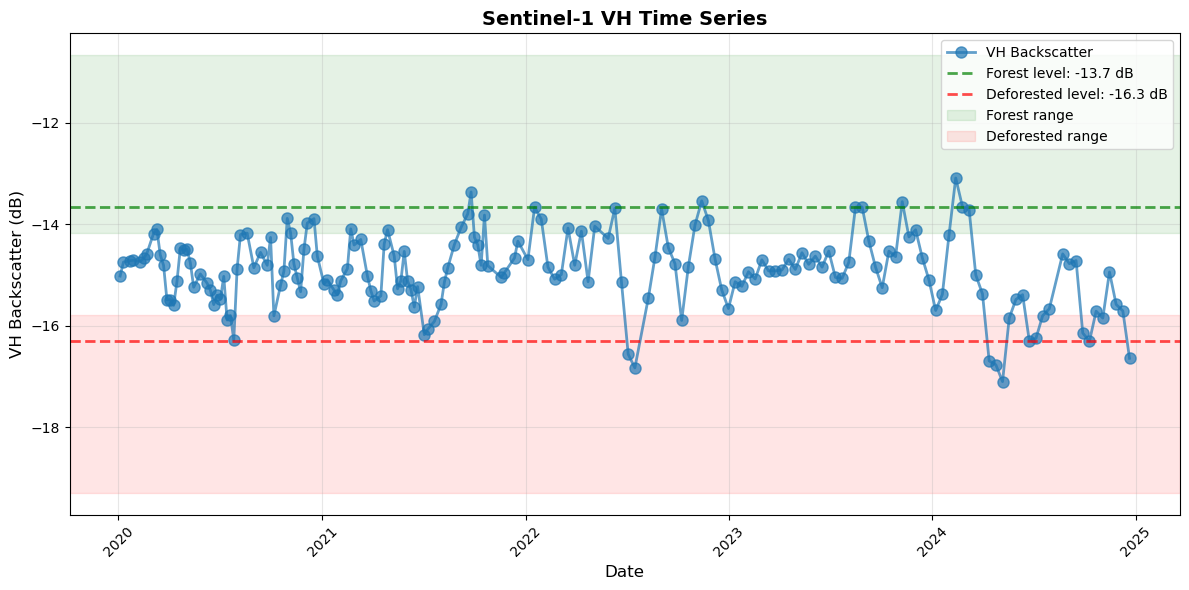


✓ Plot complete!

📊 Interpretation:
  • If values DROP from green to red line = deforestation
  • If values stay high (near green) = forest
  • If values stay low (near red) = already cleared
  • Gradual decline = possible deforestation event


In [17]:
"""
ULTRA-SIMPLE Time Series Plot
==============================
Just shows the VH time series at center point
"""

import matplotlib.pyplot as plt
from datetime import datetime

print("Plotting time series for ROI center...")

# ===================== PICK CENTER POINT =====================
bounds = roi.bounds().getInfo()['coordinates'][0]
center_lon = (bounds[0][0] + bounds[2][0]) / 2
center_lat = (bounds[0][1] + bounds[2][1]) / 2
point = ee.Geometry.Point([center_lon, center_lat])

print(f"Point: [{center_lon:.5f}, {center_lat:.5f}]")

# ===================== EXTRACT TIME SERIES =====================
print("Extracting VH values...")

# values = s1_collection.getRegion(point, 10).getInfo() 
values = s1_multitemporal.getRegion(point, 10).getInfo() 

header = values[0]
data = values[1:]

time_idx = header.index('time')
vh_idx = [i for i, name in enumerate(header) if 'VH' in str(name)][0]

times = [row[time_idx] for row in data]
vh_values = [row[vh_idx] for row in data]
dates = [datetime.fromtimestamp(t/1000) for t in times]

print(f"✓ Got {len(dates)} observations")

# ===================== GET SIMPLE PARAMETERS =====================
upper = p95.reduceRegion(ee.Reducer.first(), point, 10).getInfo()['p95']
lower = p05.reduceRegion(ee.Reducer.first(), point, 10).getInfo()['p05']

print(f"Upper boundary (forest): {upper:.2f} dB")
print(f"Lower boundary (deforested): {lower:.2f} dB")

# ===================== PLOT =====================
plt.figure(figsize=(12, 6))

plt.plot(dates, vh_values, 'o-', linewidth=2, markersize=8, alpha=0.7, label='VH Backscatter')
plt.axhline(upper, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Forest level: {upper:.1f} dB')
plt.axhline(lower, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Deforested level: {lower:.1f} dB')

# Add shading
plt.axhspan(upper-0.5, upper+3, alpha=0.1, color='green', label='Forest range')
plt.axhspan(lower-3, lower+0.5, alpha=0.1, color='red', label='Deforested range')

plt.xlabel('Date', fontsize=12)
plt.ylabel('VH Backscatter (dB)', fontsize=12)
plt.title('Sentinel-1 VH Time Series', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✓ Plot complete!")
print("\n📊 Interpretation:")
print("  • If values DROP from green to red line = deforestation")
print("  • If values stay high (near green) = forest")
print("  • If values stay low (near red) = already cleared")
print("  • Gradual decline = possible deforestation event")

## --Inspect specific pixel--

In [ ]:
"""
Simple Pixel Inspector
======================
Input UTM coordinates, get time series + diagnostics
"""

import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

def inspect_pixel(easting, northing):
    """
    Inspect a single pixel
    
    Args:
        easting: UTM Easting (e.g., 683000)
        northing: UTM Northing (e.g., 145000)
    """
    
    # Convert UTM to lon/lat for Earth Engine
    point_utm = ee.Geometry.Point([easting, northing], 'EPSG:32636')
    point_latlon = point_utm.transform('EPSG:4326')
    coords = point_latlon.coordinates().getInfo()
    
    print(f"\n📍 Pixel: [{easting}, {northing}] (UTM 32636)")
    print(f"   = [{coords[0]:.5f}, {coords[1]:.5f}] (lat/lon)")
    
    # Get time series
    values = s1_multitemporal.getRegion(point_latlon, 10).getInfo()
    header = values[0]
    data = values[1:]
    
    time_idx = header.index('time')
    vh_idx = [i for i, h in enumerate(header) if 'VH' in str(h)][0]
    
    times = [row[time_idx] for row in data if row[time_idx]]
    vh_values = [row[vh_idx] for row in data if row[time_idx]]
    dates = [datetime.fromtimestamp(t/1000) for t in times]
    
    # Get diagnostics
    diag = ee.Image([std_dev, flattening, candidate_mask, defor_mask, 
                     p95, p05]).reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=point_latlon,
        scale=10
    ).getInfo()
    
    std = diag['stdDev']
    flat = diag['flattening']
    is_candidate = bool(diag['candidates'])
    is_deforested = bool(diag['deforested'])
    upper = diag['p95']
    lower = diag['p05']
    
    # Print results
    print(f"\n📊 Results:")
    print(f"   Std Dev:     {std:.3f} dB  {'✓ High variability' if is_candidate else '✗ Low variability'}")
    print(f"   Flattening:  {flat:.3f}     {'✓ Strong drop' if is_deforested else '✗ Weak drop'}")
    print(f"   Classification: {'🪓 DEFORESTED' if is_deforested else ('⚠️ Candidate' if is_candidate else '🌲 Stable forest')}")
    
    # Plot
    plt.figure(figsize=(14, 6))
    plt.plot(dates, vh_values, 'o-', linewidth=2, markersize=8, label='VH')
    plt.axhline(upper, color='green', linestyle='--', linewidth=2, label=f'Forest: {upper:.1f} dB')
    plt.axhline(lower, color='red', linestyle='--', linewidth=2, label=f'Deforested: {lower:.1f} dB')
    plt.fill_between(dates, upper-1, upper+2, alpha=0.1, color='green')
    plt.fill_between(dates, lower-2, lower+1, alpha=0.1, color='red')
    
    status = "🪓 DEFORESTED" if is_deforested else ("⚠️ CANDIDATE" if is_candidate else "🌲 STABLE")
    plt.title(f'{status} | UTM: [{easting}, {northing}] | std={std:.2f}, flat={flat:.2f}', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('VH Backscatter (dB)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ===================== USE IT =====================
# Just input your UTM coordinates here:

inspect_pixel(683000, 145000)  # Example - replace with your coordinates

#or multiple points:
# inspect_pixel(683500, 145200)
# inspect_pixel(684000, 144800)
# inspect_pixel(682750, 145600)